Purpose
- Build reproducible figures on Timeboost auction performance and behavior.

Data needed/used
- onchain_data/auction_resolved.tsv (TSV): rounds with columns such as `round`, `first_price_bidder`, `first_price_amount`, `price`, `round_start_timestamp`, `round_end_timestamp`.
- onchain_data/timeboosted_swaps_*.csv (CSV): timeboosted swaps with `timestamp`, `tx_hash`, `token_in`, `token_out`, `amount_in`, `amount_out`, `gas_used`, `effective_gas_price`.
- price_tables/prices_consolidated.tsv (TSV): per-second consolidated prices with `timestamp`, `address`, `price`.
- (optional) auction_resolved_with_markouts.csv: per-round aggregates joined with 1s markouts and USD conversions.

Figures
- Daily count and daily volume of detected CEX-DEX trades
- Daily market share by round count (Top3 and Others)
- Correlation of bid vs. sum of 1s markouts in first 5/10/15/30/60 seconds of each round
- OLS fits on Top 3 bidders’ bid vs. markout over round

In [1]:
# Imports and global settings
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import optimize as opt
import statsmodels.api as sm
from tabulate import tabulate

# Fancy global styling
plt.style.use("seaborn-v0_8-talk")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.bbox": "tight",
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "font.family": "serif",  # or "DejaVu Serif"; set LaTeX if you like
        "text.usetex": False,  # True if your LaTeX toolchain is installed
    }
)

In [2]:
# Paths and constants
ROOT_DIR = Path(__file__).parent if "__file__" in globals() else Path.cwd()
ONCHAIN_DIR = ROOT_DIR / "onchain_data"
PRICE_DIR = ROOT_DIR / "price_tables"

SWAPS_GLOB = "timeboosted_swaps_*.csv"
AUCTION_RESOLVED_PATH = ONCHAIN_DIR / "auction_resolved.tsv"
PRICES_PATH = PRICE_DIR / "prices_consolidated.tsv"
AGG_MARKOUT_PATH = ROOT_DIR / "auction_resolved_with_markouts.csv"

# Supported token addresses (case-insensitive)
ETH_ADDRESS = "0x82aF49447D8a07e3bd95BD0d56f35241523fBab1"
BTC_ADDRESS = "0x2f2a2543B76A4166549F7aaB2e75Bef0aefC5B0f"
USDC_ADDRESS = "0xaf88d065e77c8cC2239327C5EDb3A432268e5831"
USDCE_ADDRESS = "0xFF970A61A04b1cA14834A43f5dE4533eBDDB5CC8"
USDT_ADDRESS = "0xFd086bC7CD5C481DCC9C85ebE478A1C0b69FCbb9"

ETH_ADDR_L = ETH_ADDRESS.lower()
BTC_ADDR_L = BTC_ADDRESS.lower()
USDC_ADDR_L = USDC_ADDRESS.lower()
USDCE_ADDR_L = USDCE_ADDRESS.lower()
USDT_ADDR_L = USDT_ADDRESS.lower()
SUPPORTED_ADDRS_LOWER = {ETH_ADDR_L, BTC_ADDR_L, USDC_ADDR_L, USDCE_ADDR_L, USDT_ADDR_L}

WEI_PER_ETH = 10**18

# Horizons in seconds (include 1s; exclude 5s)
HORIZONS = [1]

# Date range for filtering rounds in figures (adjust if needed)
START_TS = int(datetime(2025, 6, 1, tzinfo=timezone.utc).timestamp())
END_TS = int(datetime(2025, 8, 31, 23, 59, 59, tzinfo=timezone.utc).timestamp())

# filter only transactions with positive markouts
tx_positive_only = True

## Shared datasets and objects (index)

Run the "Unified datasets & precomputations" cell to materialize these objects. Shapes can be checked with `.shape`.

- **`rounds_df`**: Polars DataFrame of per-round aggregates.
  - **Purpose**: Contains bidder metadata, USD conversions, and aggregated 1s markouts per horizon.
  - **Columns (subset)**: `__row_id__`, `round`, `first_price_bidder`, `block_number`, `round_start_timestamp`, `round_end_timestamp`, `eth_price_at_round_start`, `bid_in_usd`, `payment_in_usd`, `agg_markout_1s` (and for any other horizons in `HORIZONS`).

- **`prices_all`**: Polars DataFrame of per-second prices for supported addresses.
  - **Purpose**: Pricing source for USD conversions and markouts.
  - **Columns**: `timestamp`(i64), `price`(f64), `address`(str; lowercase). Includes synthetic USDCE=USDC and USDT=1.0.

- **`swaps_base`**: Polars DataFrame of normalized timeboosted swaps (supported tokens only).
  - **Purpose**: Base swap records used across analyses.
  - **Columns**: `timestamp`(i64), `tx_hash`(str), `token_in_addr`(str), `token_out_addr`(str), `gas_used`(i64), `effective_gas_price`(i64), `amount_in`(f64), `amount_out`(f64).

- **`per_tx_notional`**: Polars DataFrame of per-transaction USD notional.
  - **Purpose**: Daily counts/volume and other per-tx analyses.
  - **Columns**: `tx_hash`, `tx_timestamp`(i64), `tx_notional_usd`(f64).

- **`swaps_1s_small`**: Polars DataFrame of swap-level 1s markout and offset within round.
  - **Purpose**: First-X-seconds correlation/aggregation.
  - **Columns**: `__row_id__`, `offset_s`(0..59), `swap_markout_usd_1s`(f64).

- **`per_tx_mapped_1s`**: Polars DataFrame of per-tx 1s markout minus gas with round metadata.
  - **Purpose**: Inspect extremes; join txs to rounds.
  - **Columns (subset)**: `tx_hash`, `tx_timestamp`(i64), `tx_markout_minus_gas_usd_1s`(f64), `gas_used_first`, `effective_gas_price_first`, `gas_cost_eth`, `tx_timestamp_plus`, `eth_price_tp`, `gas_cost_usd`, plus round fields: `round`, `block_number`, `first_price_bidder`, `round_start_timestamp`, `round_end_timestamp`.

- **Constants**: `HORIZONS` (list[int]), `H_DEF`(int=1), `START_TS`/`END_TS` (ints or None), `tx_positive_only` (bool).

Example: print shapes after running the unified datasets cell:
```python
rounds_df.shape, per_tx_notional.shape, swaps_1s_small.shape, per_tx_mapped_1s.shape
```


In [3]:
# Helper functions

def get_swap_paths():
    """Return list of CSV paths for timeboosted swaps.
    Raises if none found.
    """
    files = sorted(ONCHAIN_DIR.glob(SWAPS_GLOB))
    if not files:
        raise FileNotFoundError(
            f"No swap files found matching: {ONCHAIN_DIR / SWAPS_GLOB}"
        )
    return files


def read_swaps() -> pl.DataFrame:
    """Load and normalize timeboosted swaps for supported tokens.

    Returns a Polars DataFrame with columns:
    - timestamp (i64): seconds since epoch (UTC)
    - tx_hash (str)
    - token_in_addr (str, lowercase)
    - token_out_addr (str, lowercase)
    - gas_used (i64)
    - effective_gas_price (i64, wei)
    - amount_in (f64, token units)
    - amount_out (f64, token units)
    Only rows where either leg is one of SUPPORTED_ADDRS_LOWER are kept.
    Applies START_TS/END_TS time window if provided.
    """
    _ = get_swap_paths()
    pattern = str(ONCHAIN_DIR / SWAPS_GLOB)
    lf = pl.scan_csv(pattern, infer_schema_length=0)
    lf = lf.with_columns(
        [
            pl.col("timestamp").cast(pl.Int64),
            pl.col("tx_hash").cast(pl.String),
            pl.col("token_in").str.to_lowercase().alias("token_in_addr"),
            pl.col("token_out").str.to_lowercase().alias("token_out_addr"),
            pl.col("gas_used").cast(pl.Int64),
            pl.col("effective_gas_price").cast(pl.Int64),
            pl.col("amount_in").cast(pl.Float64),
            pl.col("amount_out").cast(pl.Float64),
        ]
    ).filter(
        pl.col("token_in_addr").is_in(list(SUPPORTED_ADDRS_LOWER))
        | pl.col("token_out_addr").is_in(list(SUPPORTED_ADDRS_LOWER))
    )
    if START_TS is not None:
        lf = lf.filter(pl.col("timestamp") >= pl.lit(int(START_TS)))
    if END_TS is not None:
        lf = lf.filter(pl.col("timestamp") <= pl.lit(int(END_TS)))
    return lf.collect()


def read_prices_for_supported() -> pl.DataFrame:
    """Load per-second consolidated prices for supported addresses.

    Returns a Polars DataFrame with columns:
    - timestamp (i64)
    - price (f64, USD)
    - address (str, lowercase)
    Includes synthetic USDCE=USDC and USDT=1.0 price series on all timestamps.
    """
    prices = pl.read_csv(
        PRICES_PATH,
        separator="\t",
        infer_schema_length=0,
        try_parse_dates=False,
    )
    prices = prices.with_columns(
        [
            pl.col("timestamp").cast(pl.Int64),
            pl.col("address").str.to_lowercase().alias("address"),
            pl.col("price").cast(pl.Float64),
        ]
    ).filter(pl.col("address").is_in(list(SUPPORTED_ADDRS_LOWER)))
    usdc_prices = prices.filter(pl.col("address") == USDC_ADDR_L)
    usdce_prices = usdc_prices.with_columns(
        pl.lit(USDCE_ADDR_L).alias("address")
    ).select(["timestamp", "price", "address"])
    all_ts = prices.select(pl.col("timestamp")).unique()
    usdt_prices = all_ts.with_columns(
        [
            pl.lit(USDT_ADDR_L).alias("address"),
            pl.lit(1.0).alias("price"),
        ]
    ).select(["timestamp", "price", "address"])
    prices = prices.select(["timestamp", "price", "address"])
    prices = pl.concat([prices, usdce_prices, usdt_prices])
    return prices


def compute_per_swap_markout(
    swaps: pl.DataFrame, prices: pl.DataFrame, horizon_s: int
) -> pl.DataFrame:
    """Compute markout at horizon for each swap.

    Inputs:
    - swaps: see read_swaps()
    - prices: see read_prices_for_supported()
    - horizon_s: seconds forward from swap timestamp

    Output columns (in addition to input swap columns):
    - timestamp_plus (i64)
    - price_out_tp (f64) price of token_out at t+h
    - price_in_tp (f64) price of token_in at t+h
    - swap_markout_usd_{h}s (f64)
    """
    swaps_plus = swaps.with_columns(
        (pl.col("timestamp") + horizon_s).alias("timestamp_plus")
    )
    p_tp_out = prices.rename({"price": "price_out_tp"})
    swaps_out = swaps_plus.join(
        p_tp_out,
        left_on=["token_out_addr", "timestamp_plus"],
        right_on=["address", "timestamp"],
        how="left",
    )
    p_tp_in = prices.rename({"price": "price_in_tp"})
    swaps_io = swaps_out.join(
        p_tp_in,
        left_on=["token_in_addr", "timestamp_plus"],
        right_on=["address", "timestamp"],
        how="left",
    )
    return swaps_io.with_columns(
        (
            pl.col("amount_out") * pl.col("price_out_tp").fill_null(0.0)
            - pl.col("amount_in") * pl.col("price_in_tp").fill_null(0.0)
        ).alias(f"swap_markout_usd_{horizon_s}s")
    )


def compute_per_tx_markout_minus_gas(
    swaps_with_markout: pl.DataFrame, prices: pl.DataFrame, horizon_s: int
) -> pl.DataFrame:
    """Aggregate swap markouts per transaction and subtract gas cost in USD.

    Output columns include:
    - tx_hash (str)
    - tx_timestamp (i64)
    - tx_markout_usd_{h}s (f64)
    - gas_used_first (i64), effective_gas_price_first (i64)
    - gas_cost_eth (f64), eth_price_tp (f64), gas_cost_usd (f64)
    - tx_markout_minus_gas_usd_{h}s (f64)
    If tx_positive_only is True, only rows with positive tx_markout_minus_gas are kept.
    """
    per_tx = swaps_with_markout.group_by("tx_hash").agg(
        [
            pl.col("timestamp").min().alias("tx_timestamp"),
            pl.col(f"swap_markout_usd_{horizon_s}s")
            .sum()
            .alias(f"tx_markout_usd_{horizon_s}s"),
            pl.col("gas_used").first().alias("gas_used_first"),
            pl.col("effective_gas_price").first().alias("effective_gas_price_first"),
        ]
    )
    per_tx = per_tx.with_columns(
        [
            (
                pl.col("gas_used_first")
                * pl.col("effective_gas_price_first")
                / WEI_PER_ETH
            ).alias("gas_cost_eth"),
            (pl.col("tx_timestamp") + horizon_s).alias("tx_timestamp_plus"),
        ]
    )
    eth_prices = (
        prices.filter(pl.col("address") == ETH_ADDR_L)
        .select(["timestamp", "price"])
        .rename({"price": "eth_price_tp"})
    )
    per_tx = per_tx.join(
        eth_prices, left_on="tx_timestamp_plus", right_on="timestamp", how="left"
    )
    per_tx = per_tx.with_columns(
        [
            (pl.col("gas_cost_eth") * pl.col("eth_price_tp").fill_null(0.0)).alias(
                "gas_cost_usd"
            ),
            (
                pl.col(f"tx_markout_usd_{horizon_s}s")
                - pl.col("gas_cost_eth") * pl.col("eth_price_tp").fill_null(0.0)
            ).alias(f"tx_markout_minus_gas_usd_{horizon_s}s"),
        ]
    )
    return (
        per_tx.filter(pl.col(f"tx_markout_minus_gas_usd_{horizon_s}s") > 0)
        if tx_positive_only
        else per_tx
    )


def read_auction_resolved() -> pl.DataFrame:
    """Load auction rounds TSV and restrict by configured date range.

    Returns a Polars DataFrame with columns including (not exhaustive):
    - round (str)
    - first_price_bidder (str)
    - first_price_amount (str/int in wei)
    - price (str/int in wei)
    - round_start_timestamp (i64)
    - round_end_timestamp (i64)
    - block_number (i64)
    Plus an added index column: __row_id__ (u32).
    """
    ar = pl.read_csv(
        AUCTION_RESOLVED_PATH,
        separator="\t",
        infer_schema_length=0,
        try_parse_dates=False,
    )
    ar = ar.with_columns(
        [
            pl.col("round_start_timestamp").cast(pl.Int64),
            pl.col("round_end_timestamp").cast(pl.Int64),
        ]
    )
    if START_TS is not None:
        ar = ar.filter(pl.col("round_end_timestamp") >= pl.lit(int(START_TS)))
    if END_TS is not None:
        ar = ar.filter(pl.col("round_end_timestamp") <= pl.lit(int(END_TS)))
    ar = ar.with_row_index(name="__row_id__")
    return ar


def map_transactions_to_rounds(per_tx: pl.DataFrame, ar: pl.DataFrame) -> pl.DataFrame:
    """Map transactions (by tx_timestamp) to rounds via backward asof join.

    Keeps only transactions whose timestamps fall within the matched
    [round_start_timestamp, round_end_timestamp] window.

    Returns per_tx columns plus joined round metadata.
    """
    per_tx_sorted = per_tx.sort("tx_timestamp")
    ar_sorted = ar.sort("round_start_timestamp")
    joined = per_tx_sorted.join_asof(
        ar_sorted,
        left_on="tx_timestamp",
        right_on="round_start_timestamp",
        strategy="backward",
    )
    mapped = joined.filter(pl.col("tx_timestamp") <= pl.col("round_end_timestamp"))
    return mapped


def build_round_aggregates_for_horizons(horizons: list[int]) -> pl.DataFrame:
    """Build per-round aggregates, including USD bid/payment and agg markouts.

    For each horizon h in horizons, computes agg_markout_{h}s by:
    swaps -> per-tx markout minus gas -> map to rounds -> sum per __row_id__.

    Returns the auction rounds with added columns:
    - eth_price_at_round_start (f64)
    - bid_in_usd (f64)
    - payment_in_usd (f64)
    - agg_markout_{h}s (f64 for each h)
    """
    swaps = read_swaps()
    prices = read_prices_for_supported()
    ar = read_auction_resolved()
    out = ar
    # Add ETH price at round start for USD conversions
    eth_at_start = (
        prices.filter(pl.col("address") == ETH_ADDR_L)
        .select(["timestamp", "price"])
        .rename({"price": "eth_price_at_round_start"})
    )
    out = out.join(
        eth_at_start, left_on="round_start_timestamp", right_on="timestamp", how="left"
    )
    # Bid/payment USD
    out = out.with_columns(
        [
            (
                pl.col("first_price_amount").cast(pl.Float64)
                / WEI_PER_ETH
                * pl.col("eth_price_at_round_start").fill_null(0.0)
            ).alias("bid_in_usd"),
            (
                pl.col("price").cast(pl.Float64)
                / WEI_PER_ETH
                * pl.col("eth_price_at_round_start").fill_null(0.0)
            ).alias("payment_in_usd"),
        ]
    )
    # For each horizon compute per-tx -> map to rounds -> sum per row_id
    for h in horizons:
        swaps_h = compute_per_swap_markout(swaps, prices, h)
        per_tx_h = compute_per_tx_markout_minus_gas(swaps_h, prices, h)
        mapped_h = map_transactions_to_rounds(per_tx_h, ar)
        summed_h = mapped_h.group_by("__row_id__").agg(
            pl.col(f"tx_markout_minus_gas_usd_{h}s").sum().alias(f"agg_markout_{h}s")
        )
        out = out.join(summed_h, on="__row_id__", how="left")
        out = out.with_columns(pl.col(f"agg_markout_{h}s").fill_null(0.0))
    return out


def to_utc_date(ts: pl.Series) -> pl.Series:
    """Convert epoch seconds to UTC date string YYYY-MM-DD (Polars expression).

    Input: a Polars Series of integers (seconds since epoch)
    Output: a Polars Series of strings (UTC date, e.g., "2025-07-15").
    """
    return (
        (ts.cast(pl.Int64) * 1000)
        .dt.with_time_unit("ms")
        .dt.convert_time_zone("UTC")
        .dt.strftime("%Y-%m-%d")
    )


def _draw_ols(ax, df: pd.DataFrame, title: str, color_line: str, q_low: float = 0.01, q_high: float = 0.99) -> None:
    """Draw scatter and OLS fit line on axes.

    - df columns: ["bid_in_usd" (float), "markout_usd" (float)]
    - Fits on full data, trims y to [q_low, q_high] for plotting clarity.
    """
    df_local = df.dropna(subset=["bid_in_usd", "markout_usd"]).copy()
    if len(df_local) >= 5 and df_local["bid_in_usd"].std() > 0:
        y = df_local["markout_usd"].to_numpy()
        ql = float(np.quantile(y, q_low))
        qh = float(np.quantile(y, q_high))
        trimmed = df_local[(df_local["markout_usd"] >= ql) & (df_local["markout_usd"] <= qh)]
        X_full = sm.add_constant(df_local[["bid_in_usd"]])
        m = sm.OLS(df_local["markout_usd"], X_full).fit()
        x_line = np.linspace(df_local["bid_in_usd"].min(), df_local["bid_in_usd"].max(), 100)
        X_line = sm.add_constant(pd.DataFrame({"bid_in_usd": x_line}))
        y_line = m.predict(X_line)
        ax.scatter(trimmed["bid_in_usd"], trimmed["markout_usd"], alpha=0.45, s=18)
        ax.plot(x_line, y_line, color=color_line, label=f"OLS fit (beta={m.params['bid_in_usd']:.6g})")
        ax.legend()
        pad = 0.05 * (qh - ql) if qh > ql else 1.0
        ax.set_ylim(ql - pad, qh + pad)
    else:
        ax.text(0.5, 0.5, "Insufficient variance", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("bid_in_usd")
    ax.set_ylabel("markout_usd")

In [4]:
# Unified datasets & precomputations (single cell)
# - rounds_df: per-round aggregates with horizon columns
# - prices_all: per-second prices for supported addresses
# - swaps_base: normalized swaps for supported addresses
# - per_tx_notional: per-transaction USD notional
# - swaps_1s_small: swap-level 1s markout and offset-in-round for first-seconds analyses

# Build rounds aggregates once
rounds_df = build_round_aggregates_for_horizons(HORIZONS)
# rounds_df columns (subset):
# [
#   "__row_id__", "round", "first_price_bidder", "block_number",
#   "round_start_timestamp", "round_end_timestamp",
#   "eth_price_at_round_start", "bid_in_usd", "payment_in_usd",
#   f"agg_markout_{HORIZONS[0]}s", ...
# ]

# Load prices and swaps once
prices_all = read_prices_for_supported()
# prices_all columns: ["timestamp" (i64), "price" (f64), "address" (str)]

swaps_base = read_swaps()
# swaps_base columns: [
#   "timestamp" (i64), "tx_hash" (str),
#   "token_in_addr" (str), "token_out_addr" (str),
#   "gas_used" (i64), "effective_gas_price" (i64),
#   "amount_in" (f64), "amount_out" (f64)
# ]

# Per-swap USD notional at t and per-transaction aggregate notional
p_in = prices_all.rename({"price": "price_in_t"})
p_out = prices_all.rename({"price": "price_out_t"})
swaps_priced = (
    swaps_base.join(
        p_in,
        left_on=["token_in_addr", "timestamp"],
        right_on=["address", "timestamp"],
        how="left",
    )
    .join(
        p_out,
        left_on=["token_out_addr", "timestamp"],
        right_on=["address", "timestamp"],
        how="left",
    )
    .with_columns(
        [
            (pl.col("amount_in") * pl.col("price_in_t").fill_null(0.0)).alias(
                "notional_in_usd"
            ),
            (pl.col("amount_out") * pl.col("price_out_t").fill_null(0.0)).alias(
                "notional_out_usd"
            ),
        ]
    )
)
# swaps_priced adds: ["price_in_t", "price_out_t", "notional_in_usd", "notional_out_usd"]

swaps_priced = swaps_priced.with_columns(
    pl.max_horizontal([pl.col("notional_in_usd"), pl.col("notional_out_usd")]).alias(
        "swap_notional_usd"
    )
)
# swaps_priced adds: ["swap_notional_usd"]

per_tx_notional = swaps_priced.group_by("tx_hash").agg(
    [
        pl.col("timestamp").min().alias("tx_timestamp"),
        pl.col("swap_notional_usd").sum().alias("tx_notional_usd"),
    ]
)
# per_tx_notional columns: ["tx_hash", "tx_timestamp", "tx_notional_usd"]

# Swap-level 1s markout and offset within round for first-seconds correlation plots
H_DEF = 1
swaps_mo_1s_tmp = compute_per_swap_markout(swaps_base, prices_all, H_DEF)
# swaps_mo_1s_tmp adds: [f"swap_markout_usd_{H_DEF}s", "timestamp_plus", "price_in_tp", "price_out_tp"]

# Map each swap to its round, then compute offset seconds in round
ar_for_map = read_auction_resolved().select(
    [
        "__row_id__",
        "round",
        "block_number",
        "first_price_bidder",
        "round_start_timestamp",
        "round_end_timestamp",
    ]
)
ar_sorted = ar_for_map.sort("round_start_timestamp")
swaps_map = swaps_mo_1s_tmp.sort("timestamp").join_asof(
    ar_sorted,
    left_on="timestamp",
    right_on="round_start_timestamp",
    strategy="backward",
)
swaps_in_round = swaps_map.filter(pl.col("timestamp") <= pl.col("round_end_timestamp"))
swaps_in_round = swaps_in_round.with_columns(
    (pl.col("timestamp") - pl.col("round_start_timestamp")).mod(60).alias("offset_s")
)
# Keep small for later joins/aggregations
swaps_1s_small = swaps_in_round.select(
    ["__row_id__", "offset_s", f"swap_markout_usd_{H_DEF}s"]
)
# swaps_1s_small columns: ["__row_id__", "offset_s", f"swap_markout_usd_{H_DEF}s"]

# Per-tx 1s markout minus gas and mapping to rounds (full metadata)
per_tx_1s = compute_per_tx_markout_minus_gas(swaps_mo_1s_tmp, prices_all, H_DEF)
# per_tx_1s columns: [
#   "tx_hash", "tx_timestamp", f"tx_markout_minus_gas_usd_{H_DEF}s",
#   "gas_used_first", "effective_gas_price_first",
#   "gas_cost_eth", "tx_timestamp_plus", "eth_price_tp", "gas_cost_usd"
# ]

per_tx_mapped_1s = per_tx_1s.sort("tx_timestamp").join_asof(
    ar_sorted,
    left_on="tx_timestamp",
    right_on="round_start_timestamp",
    strategy="backward",
).filter(pl.col("tx_timestamp") <= pl.col("round_end_timestamp"))
# Ensure required round metadata columns are retained
per_tx_mapped_1s = per_tx_mapped_1s.select(
    [
        "tx_hash",
        "tx_timestamp",
        f"tx_markout_usd_{H_DEF}s",
        f"tx_markout_minus_gas_usd_{H_DEF}s",
        "gas_used_first",
        "effective_gas_price_first",
        "gas_cost_eth",
        "tx_timestamp_plus",
        "eth_price_tp",
        "gas_cost_usd",
        "__row_id__",
        "round",
        "block_number",
        "first_price_bidder",
        "round_start_timestamp",
        "round_end_timestamp",
    ]
)

# keep only txs strictly inside the matched round window (redundant after filter but explicit)
txs_in_rounds = per_tx_mapped_1s.filter(pl.col("tx_timestamp") <= pl.col("round_end_timestamp"))
txs_in_rounds = txs_in_rounds.with_columns(
    (pl.col("tx_timestamp") - pl.col("round_start_timestamp")).mod(60).alias("offset_s")
)
# txs_in_rounds columns: ["__row_id__", "offset_s", f"swap_markout_usd_{H_DEF}s"]
# keep small for later joins/aggregations
txs_in_rounds = txs_in_rounds.select(
    ["__row_id__", "offset_s", f"tx_markout_minus_gas_usd_{H_DEF}s"]
)
# txs_in_rounds columns: ["__row_id__", "offset_s", f"swap_markout_usd_{H_DEF}s"]


In [5]:
# Inspect extremes: transactions and rounds by 1s markout (desc/asc), show top 20 with tx_hash/block_num
H_INSPECT = 1

# Use precomputed objects from the unified datasets cell
# - per_tx_mapped_1s: per-tx 1s markout minus gas with round metadata
# - rounds_df: per-round aggregates including agg_markout_1s

# Keep a rich set of columns for display
cols_tx = [
    "tx_hash",
    "tx_timestamp",
    f"tx_markout_minus_gas_usd_{H_INSPECT}s",
    "round",
    "block_number",
    "first_price_bidder",
    "round_start_timestamp",
    "round_end_timestamp",
]
print("\nTransactions — Top 20 by 1s markout (descending):")
_top_desc = (
    per_tx_mapped_1s.select(cols_tx)
    .sort(f"tx_markout_minus_gas_usd_{H_INSPECT}s", descending=True)
    .head(20)
)
print(tabulate(_top_desc.to_pandas(), headers="keys", tablefmt="psql", showindex=False))

print("\nTransactions — Bottom 20 by 1s markout (ascending):")
_bot_asc = (
    per_tx_mapped_1s.select(cols_tx)
    .sort(f"tx_markout_minus_gas_usd_{H_INSPECT}s", descending=False)
    .head(20)
)
print(tabulate(_bot_asc.to_pandas(), headers="keys", tablefmt="psql", showindex=False))

# Rounds by 1s aggregate markout
cols_rounds = [
    "round",
    "block_number",
    "first_price_bidder",
    f"agg_markout_{H_INSPECT}s",
    "bid_in_usd",
    "payment_in_usd",
    "round_start_timestamp",
    "round_end_timestamp",
]
print("\nRounds — Top 20 by aggregate 1s markout (descending):")
_rnd_top = (
    rounds_df.select(cols_rounds)
    .sort(f"agg_markout_{H_INSPECT}s", descending=True)
    .head(20)
)
print(tabulate(_rnd_top.to_pandas(), headers="keys", tablefmt="psql", showindex=False))

print("\nRounds — Bottom 20 by aggregate 1s markout (ascending):")
_rnd_bot = (
    rounds_df.select(cols_rounds)
    .sort(f"agg_markout_{H_INSPECT}s", descending=False)
    .head(20)
)
print(tabulate(_rnd_bot.to_pandas(), headers="keys", tablefmt="psql", showindex=False))


Transactions — Top 20 by 1s markout (descending):
+--------------------------------------------------------------------+----------------+-------------------------------+---------+----------------+--------------------------------------------+-------------------------+-----------------------+
| tx_hash                                                            |   tx_timestamp |   tx_markout_minus_gas_usd_1s |   round |   block_number | first_price_bidder                         |   round_start_timestamp |   round_end_timestamp |
|--------------------------------------------------------------------+----------------+-------------------------------+---------+----------------+--------------------------------------------+-------------------------+-----------------------|
| 0x7348c9362591f2924843eda8047dbdd2fbf82ce43c583c100cb004dd940e80c1 |     1750107519 |                       7173.06 |  140340 |      348072966 | 0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2 |              1750107471 |      

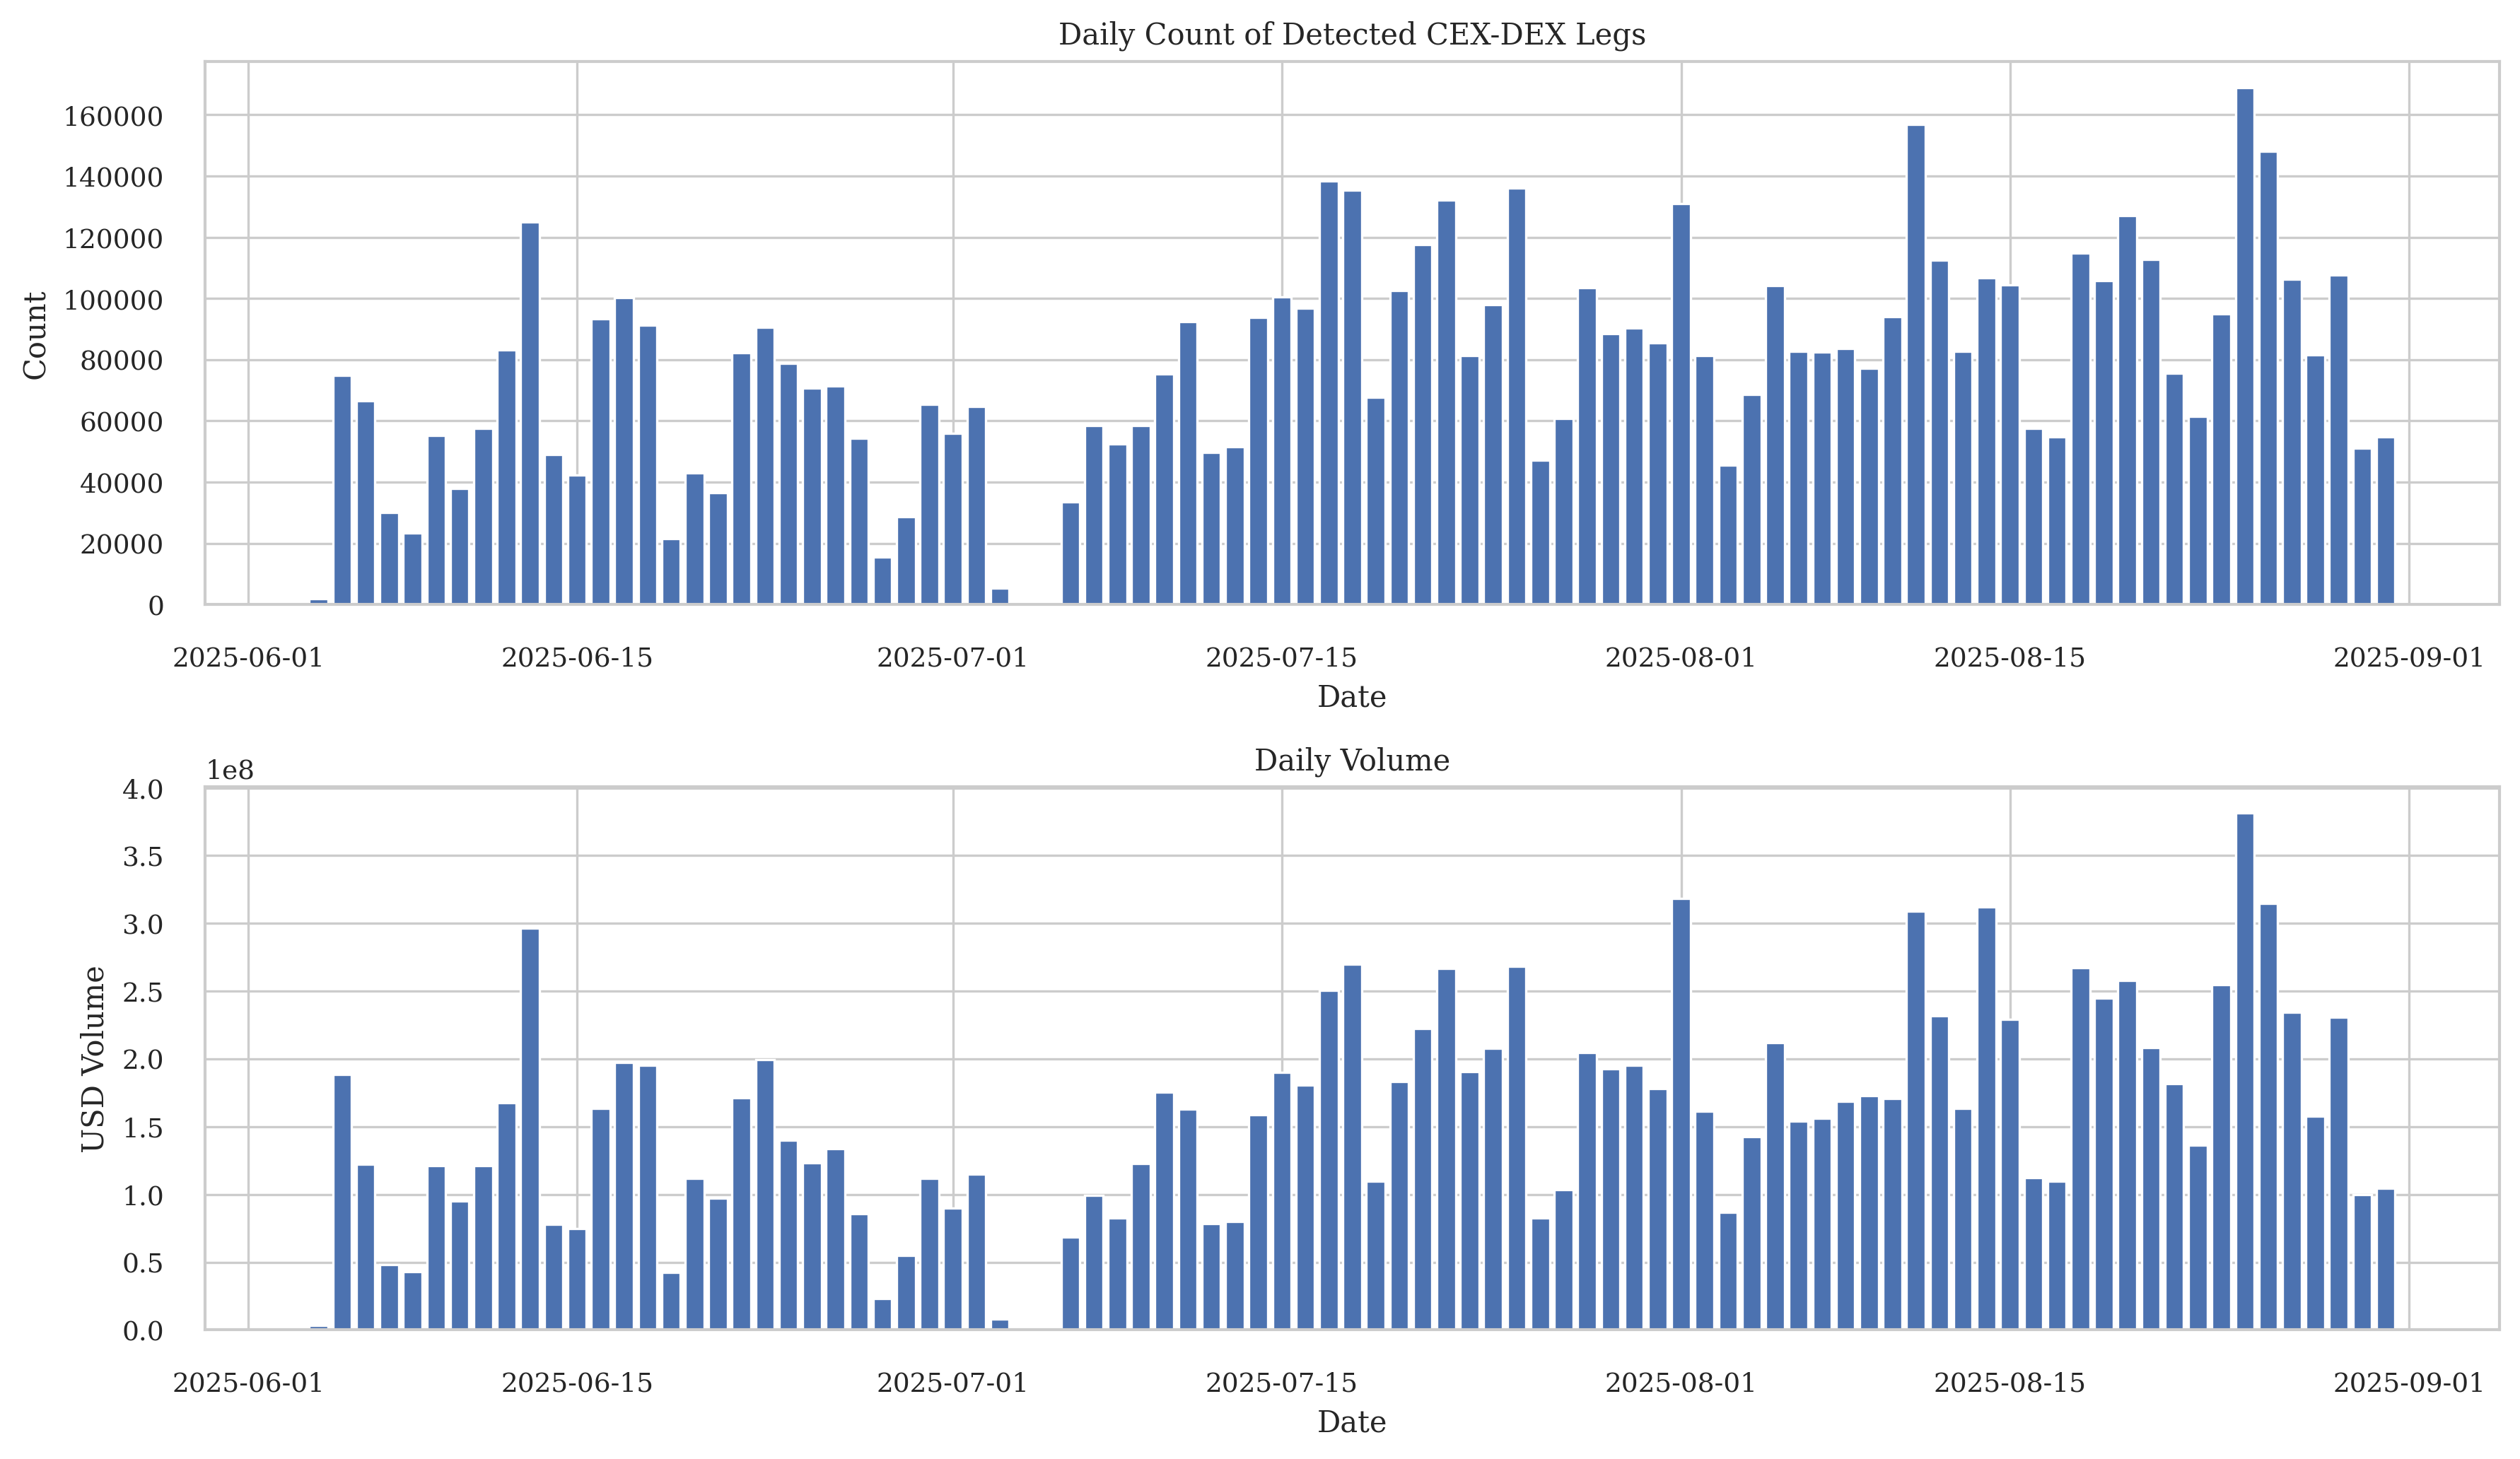

In [6]:
# Figure 1: Daily count and daily volume of detected CEX-DEX trades
# We approximate detected trades as per-transaction events in timeboosted swaps

# Build daily counts from per_tx_notional
daily_counts = (
    per_tx_notional.with_columns(
        [
            pl.from_epoch(pl.col("tx_timestamp"), time_unit="s")
            .dt.convert_time_zone("UTC")
            .alias("tx_dt"),
            pl.from_epoch(pl.col("tx_timestamp"), time_unit="s")
            .dt.date()
            .alias("tx_date"),
        ]
    )
    .group_by("tx_date")
    .agg(pl.len().alias("tx_count"))
    .sort("tx_date")
)

# Daily volume as sum of tx_notional_usd per day
daily_volume = (
    per_tx_notional.with_columns(
        [
            pl.from_epoch(pl.col("tx_timestamp"), time_unit="s")
            .dt.date()
            .alias("tx_date"),
        ]
    )
    .group_by("tx_date")
    .agg(pl.col("tx_notional_usd").sum().alias("daily_volume_usd"))
    .sort("tx_date")
)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# Daily counts
pd_daily = daily_counts.to_pandas()
axes[0].bar(pd_daily["tx_date"], pd_daily["tx_count"], width=0.8)
axes[0].set_title("Daily Count of Detected CEX-DEX Legs")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

# Daily volume
pd_daily_vol = daily_volume.to_pandas()
axes[1].bar(pd_daily_vol["tx_date"], pd_daily_vol["daily_volume_usd"], width=0.8)
axes[1].set_title("Daily Volume")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("USD Volume")
plt.tight_layout()
plt.show()

Daily share row sums (first 5):
shape: (5, 2)
┌────────────┬─────────┐
│ day_ts     ┆ row_sum │
│ ---        ┆ ---     │
│ i64        ┆ f64     │
╞════════════╪═════════╡
│ 1748649600 ┆ 1.0     │
│ 1748736000 ┆ 1.0     │
│ 1748822400 ┆ 1.0     │
│ 1748908800 ┆ 1.0     │
│ 1748995200 ┆ 1.0     │
└────────────┴─────────┘


<Figure size 4200x1800 with 0 Axes>

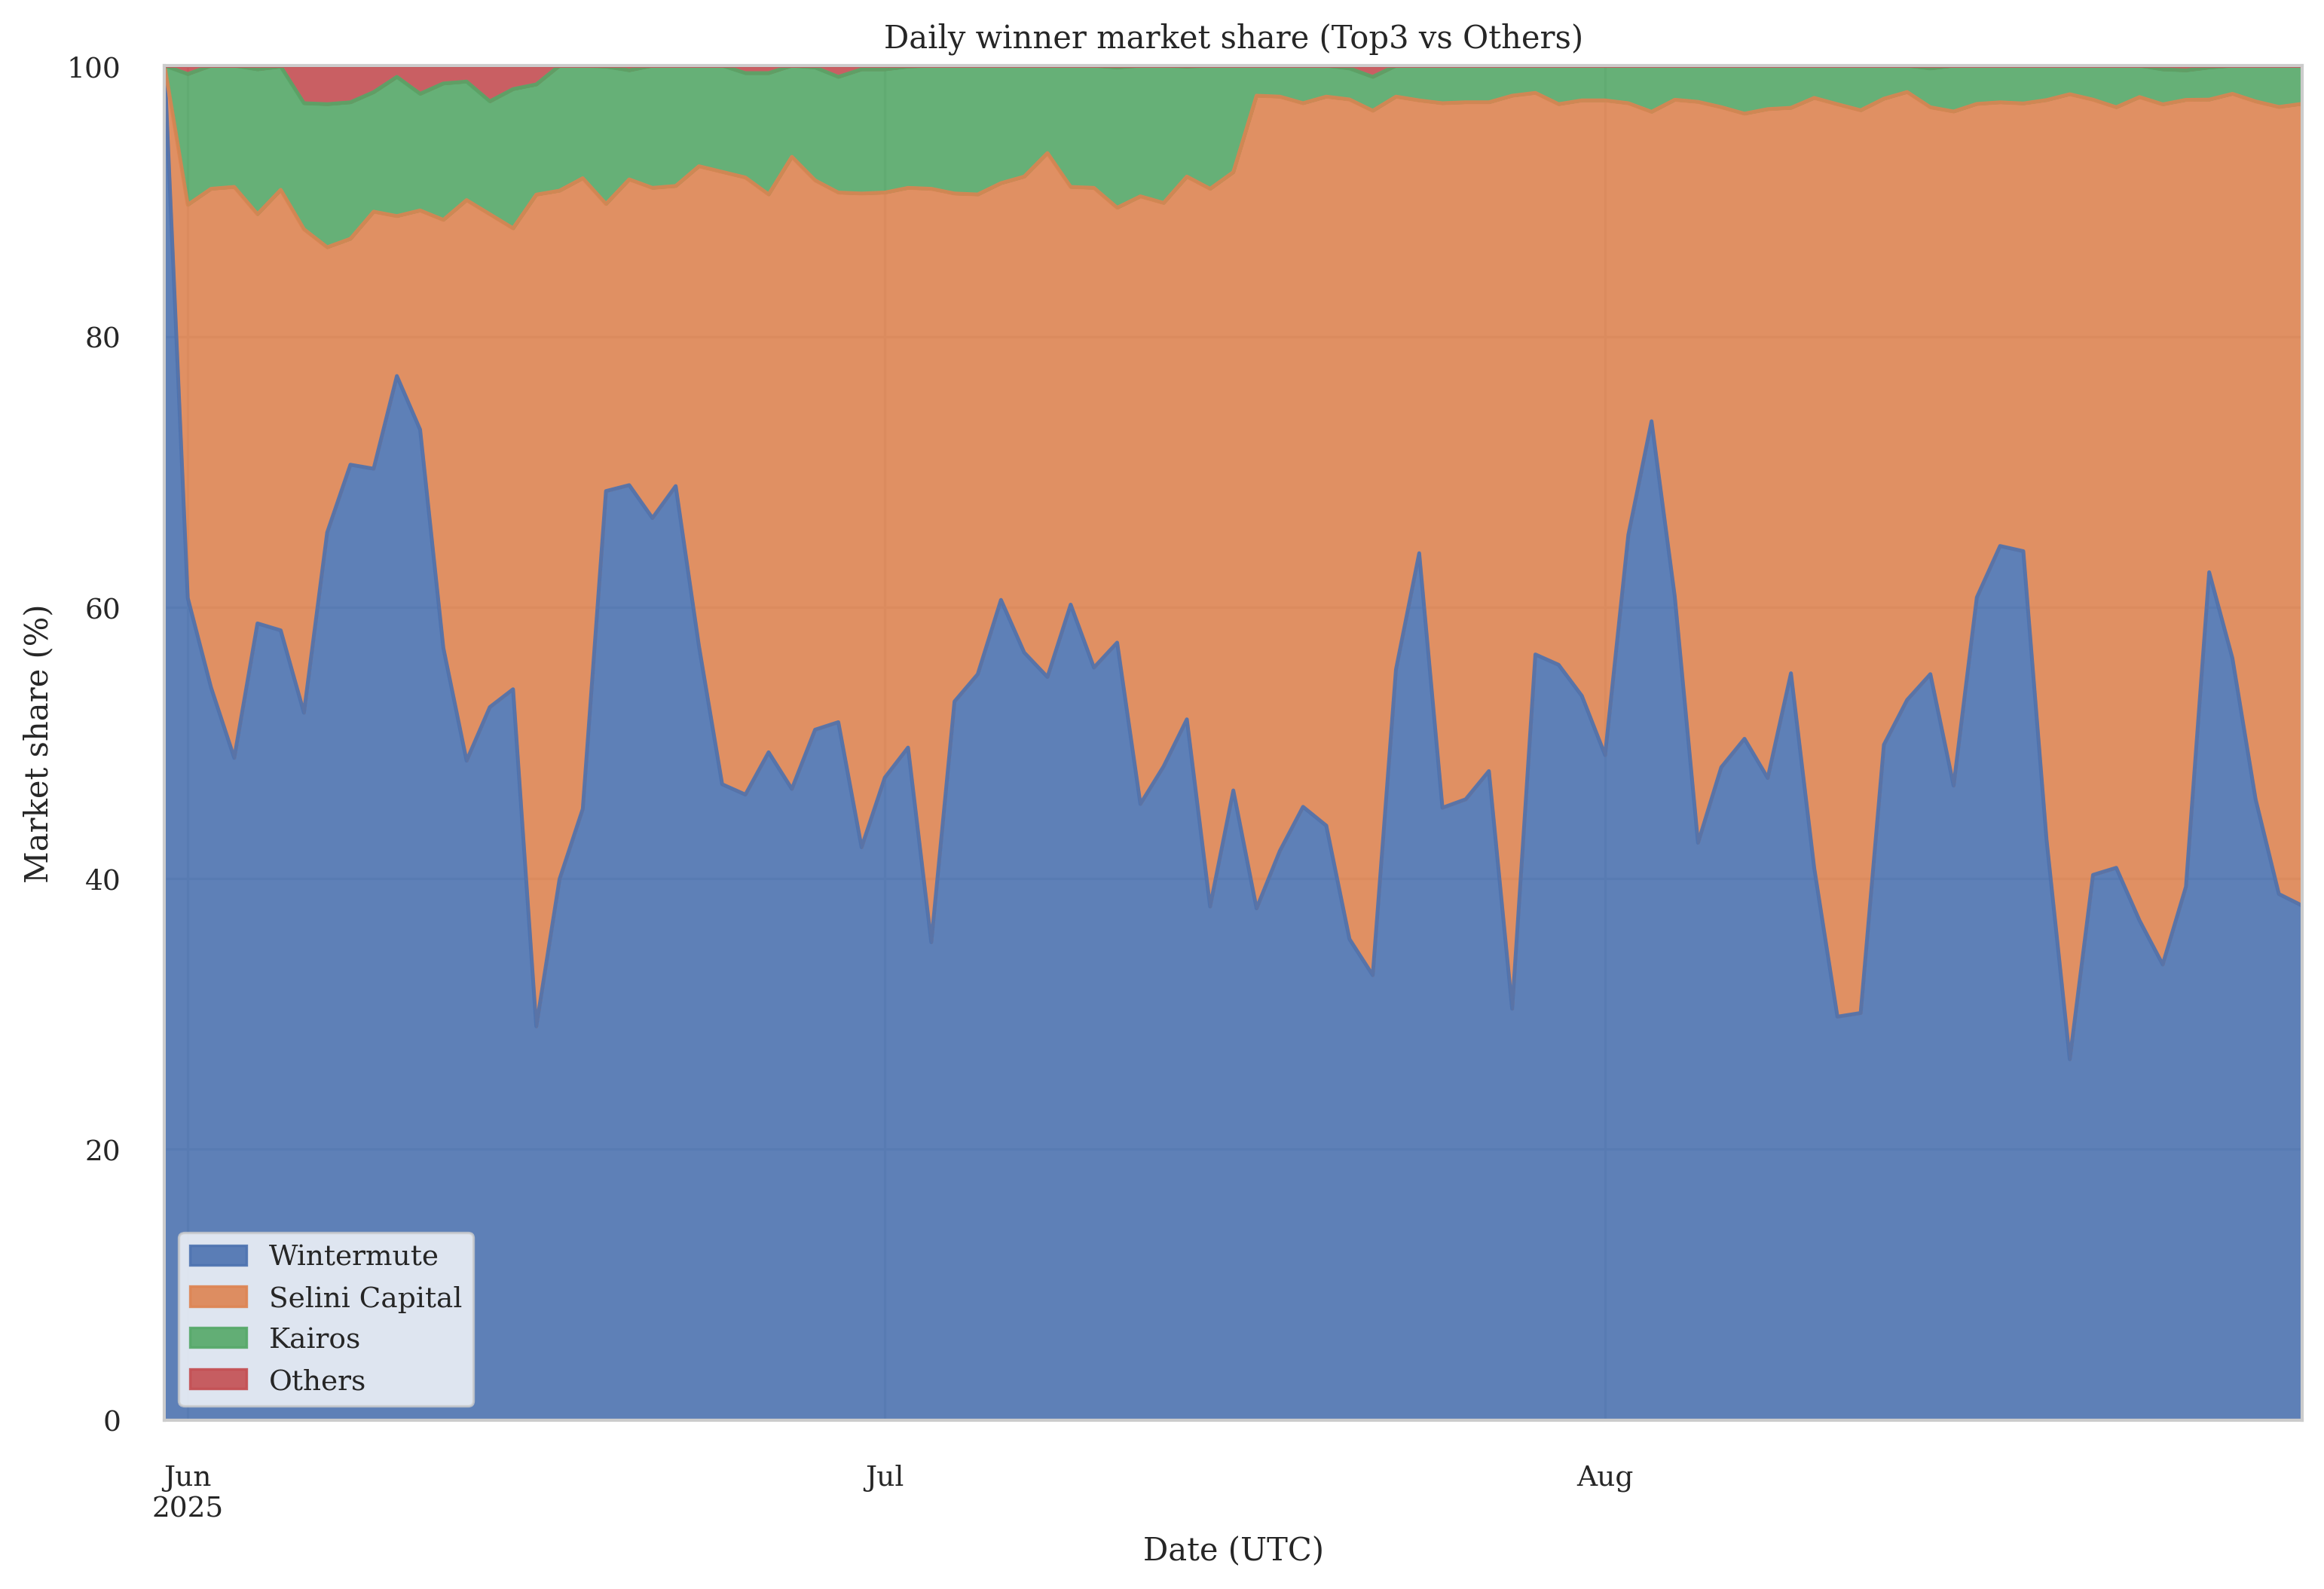

In [7]:
# Figure 2: Daily market share by winner (first_price_bidder)
# For each day: share(bidder, day) = won_rounds_i / total_rounds_of_day. Rows sum to 1.

# Build daily winner counts
daily_wins = (
    rounds_df.select(["first_price_bidder", "round_start_timestamp"])
    .with_columns(
        [
            pl.from_epoch(pl.col("round_start_timestamp"), time_unit="s")
            .dt.truncate("1d")
            .dt.epoch(time_unit="s")
            .alias("day_ts"),
        ]
    )
    .group_by(["day_ts", "first_price_bidder"])
    .agg(pl.len().alias("won_rounds"))
)

# Total per day
daily_totals = daily_wins.group_by("day_ts").agg(
    pl.col("won_rounds").sum().alias("total_rounds")
)

# Shares per bidder-day
shares_long = daily_wins.join(daily_totals, on="day_ts", how="inner").with_columns(
    (pl.col("won_rounds") / pl.col("total_rounds")).alias("share")
)

# Sanity: rows sum to 1
check = (
    shares_long.group_by("day_ts")
    .agg(pl.col("share").sum().alias("row_sum"))
    .sort("day_ts")
)
print("Daily share row sums (first 5):")
print(check.head(5))

# Collapse to Top3 + Others for a readable plot
leaders = (
    shares_long.group_by("first_price_bidder")
    .agg(pl.col("won_rounds").sum().alias("total_wins"))
    .sort("total_wins", descending=True)
    .head(3)["first_price_bidder"]
    .to_list()
)
# Friendly display names for the Top3 in rank order
friendly = {}
if len(leaders) > 0:
    friendly[leaders[0]] = "Wintermute"
if len(leaders) > 1:
    friendly[leaders[1]] = "Selini Capital"
if len(leaders) > 2:
    friendly[leaders[2]] = "Kairos"

shares_top = (
    shares_long.with_columns(
        [
            pl.when(pl.col("first_price_bidder").is_in(leaders))
            .then(
                pl.col("first_price_bidder").replace_strict(
                    friendly, default=pl.col("first_price_bidder")
                )
            )
            .otherwise(pl.lit("Others"))
            .alias("category")
        ]
    )
    .group_by(["day_ts", "category"])
    .agg(pl.col("share").sum().alias("share"))
    .sort(["day_ts", "category"])
)

# Pivot wide and plot stacked area inline
wide = shares_top.pivot(
    index="day_ts", on="category", values="share", aggregate_function="sum"
).fill_null(0)
pdf = wide.sort("day_ts").to_pandas()
pdf["datetime"] = pd.to_datetime(pdf["day_ts"], unit="s", utc=True)
pdf = pdf.drop(columns=["day_ts"]).set_index("datetime")
# Order by average share
order = pdf.mean().sort_values(ascending=False).index.tolist()
plt.figure(figsize=(14, 6))
ax = (pdf[order] * 100.0).plot.area(stacked=True, alpha=0.9)
ax.set_ylim(0, 100)
ax.margins(y=0)
plt.ylabel("Market share (%)")
plt.xlabel("Date (UTC)")
plt.title("Daily winner market share (Top3 vs Others)")
plt.tight_layout()
plt.show()

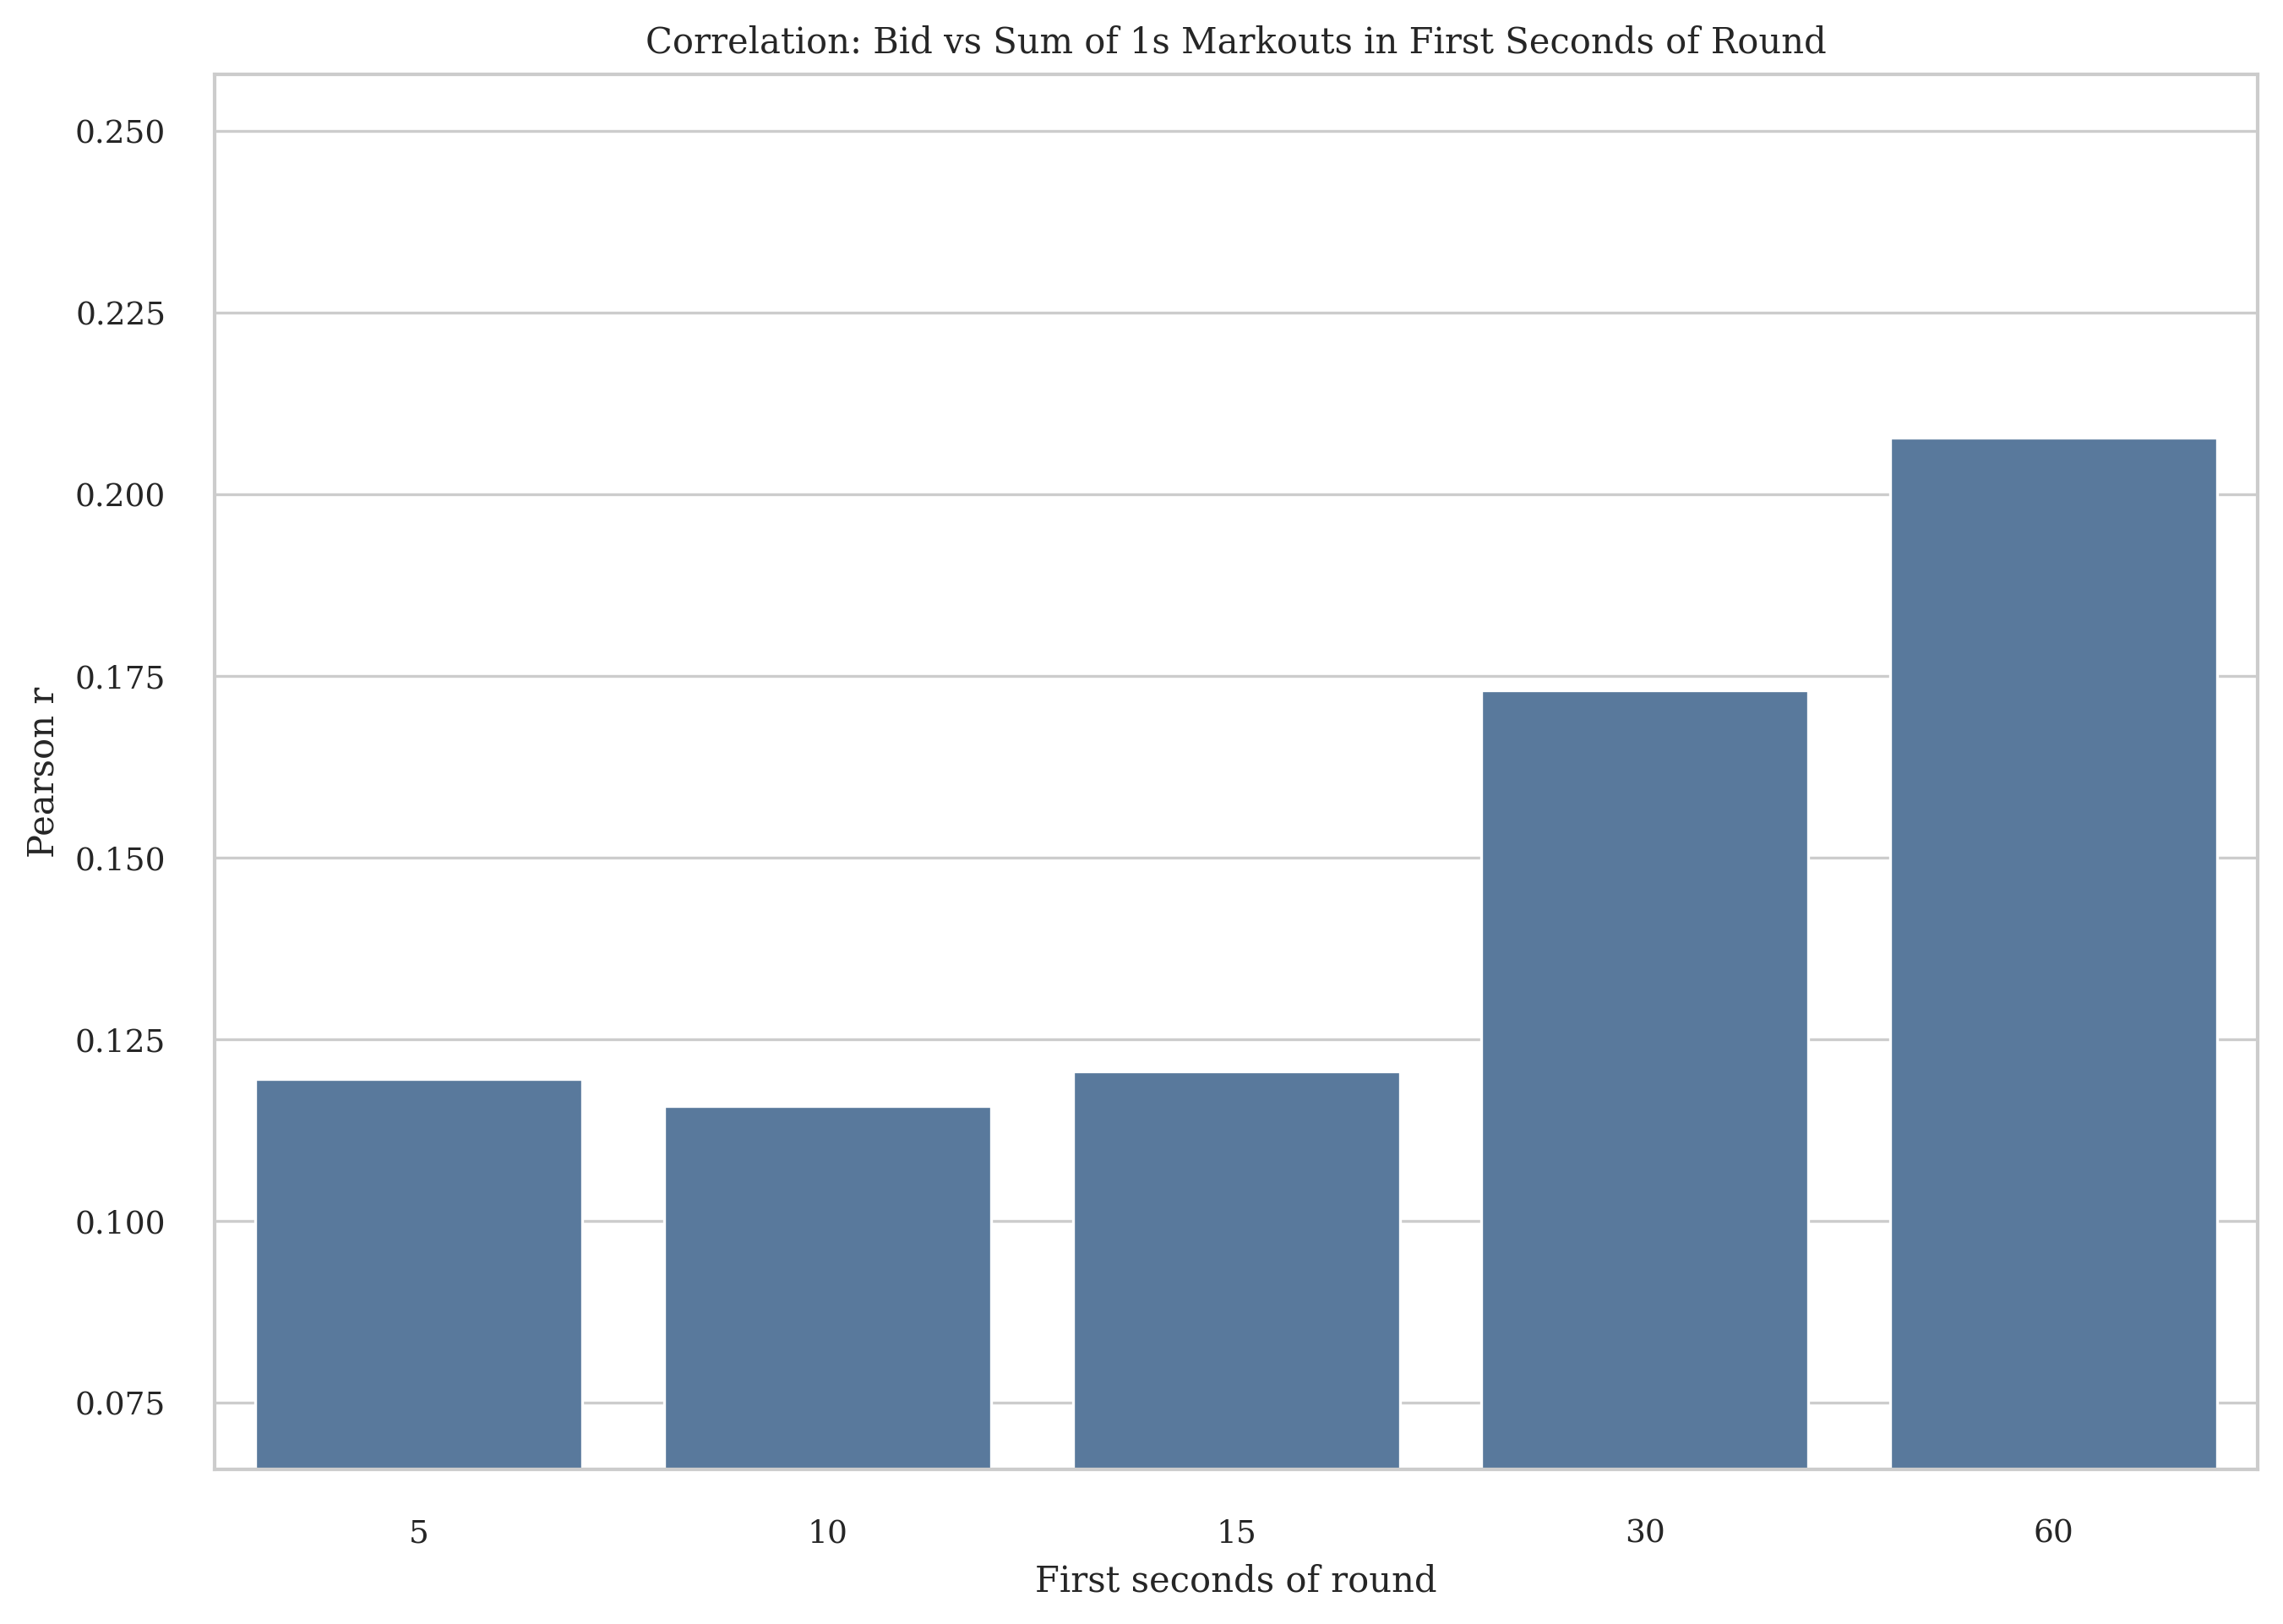

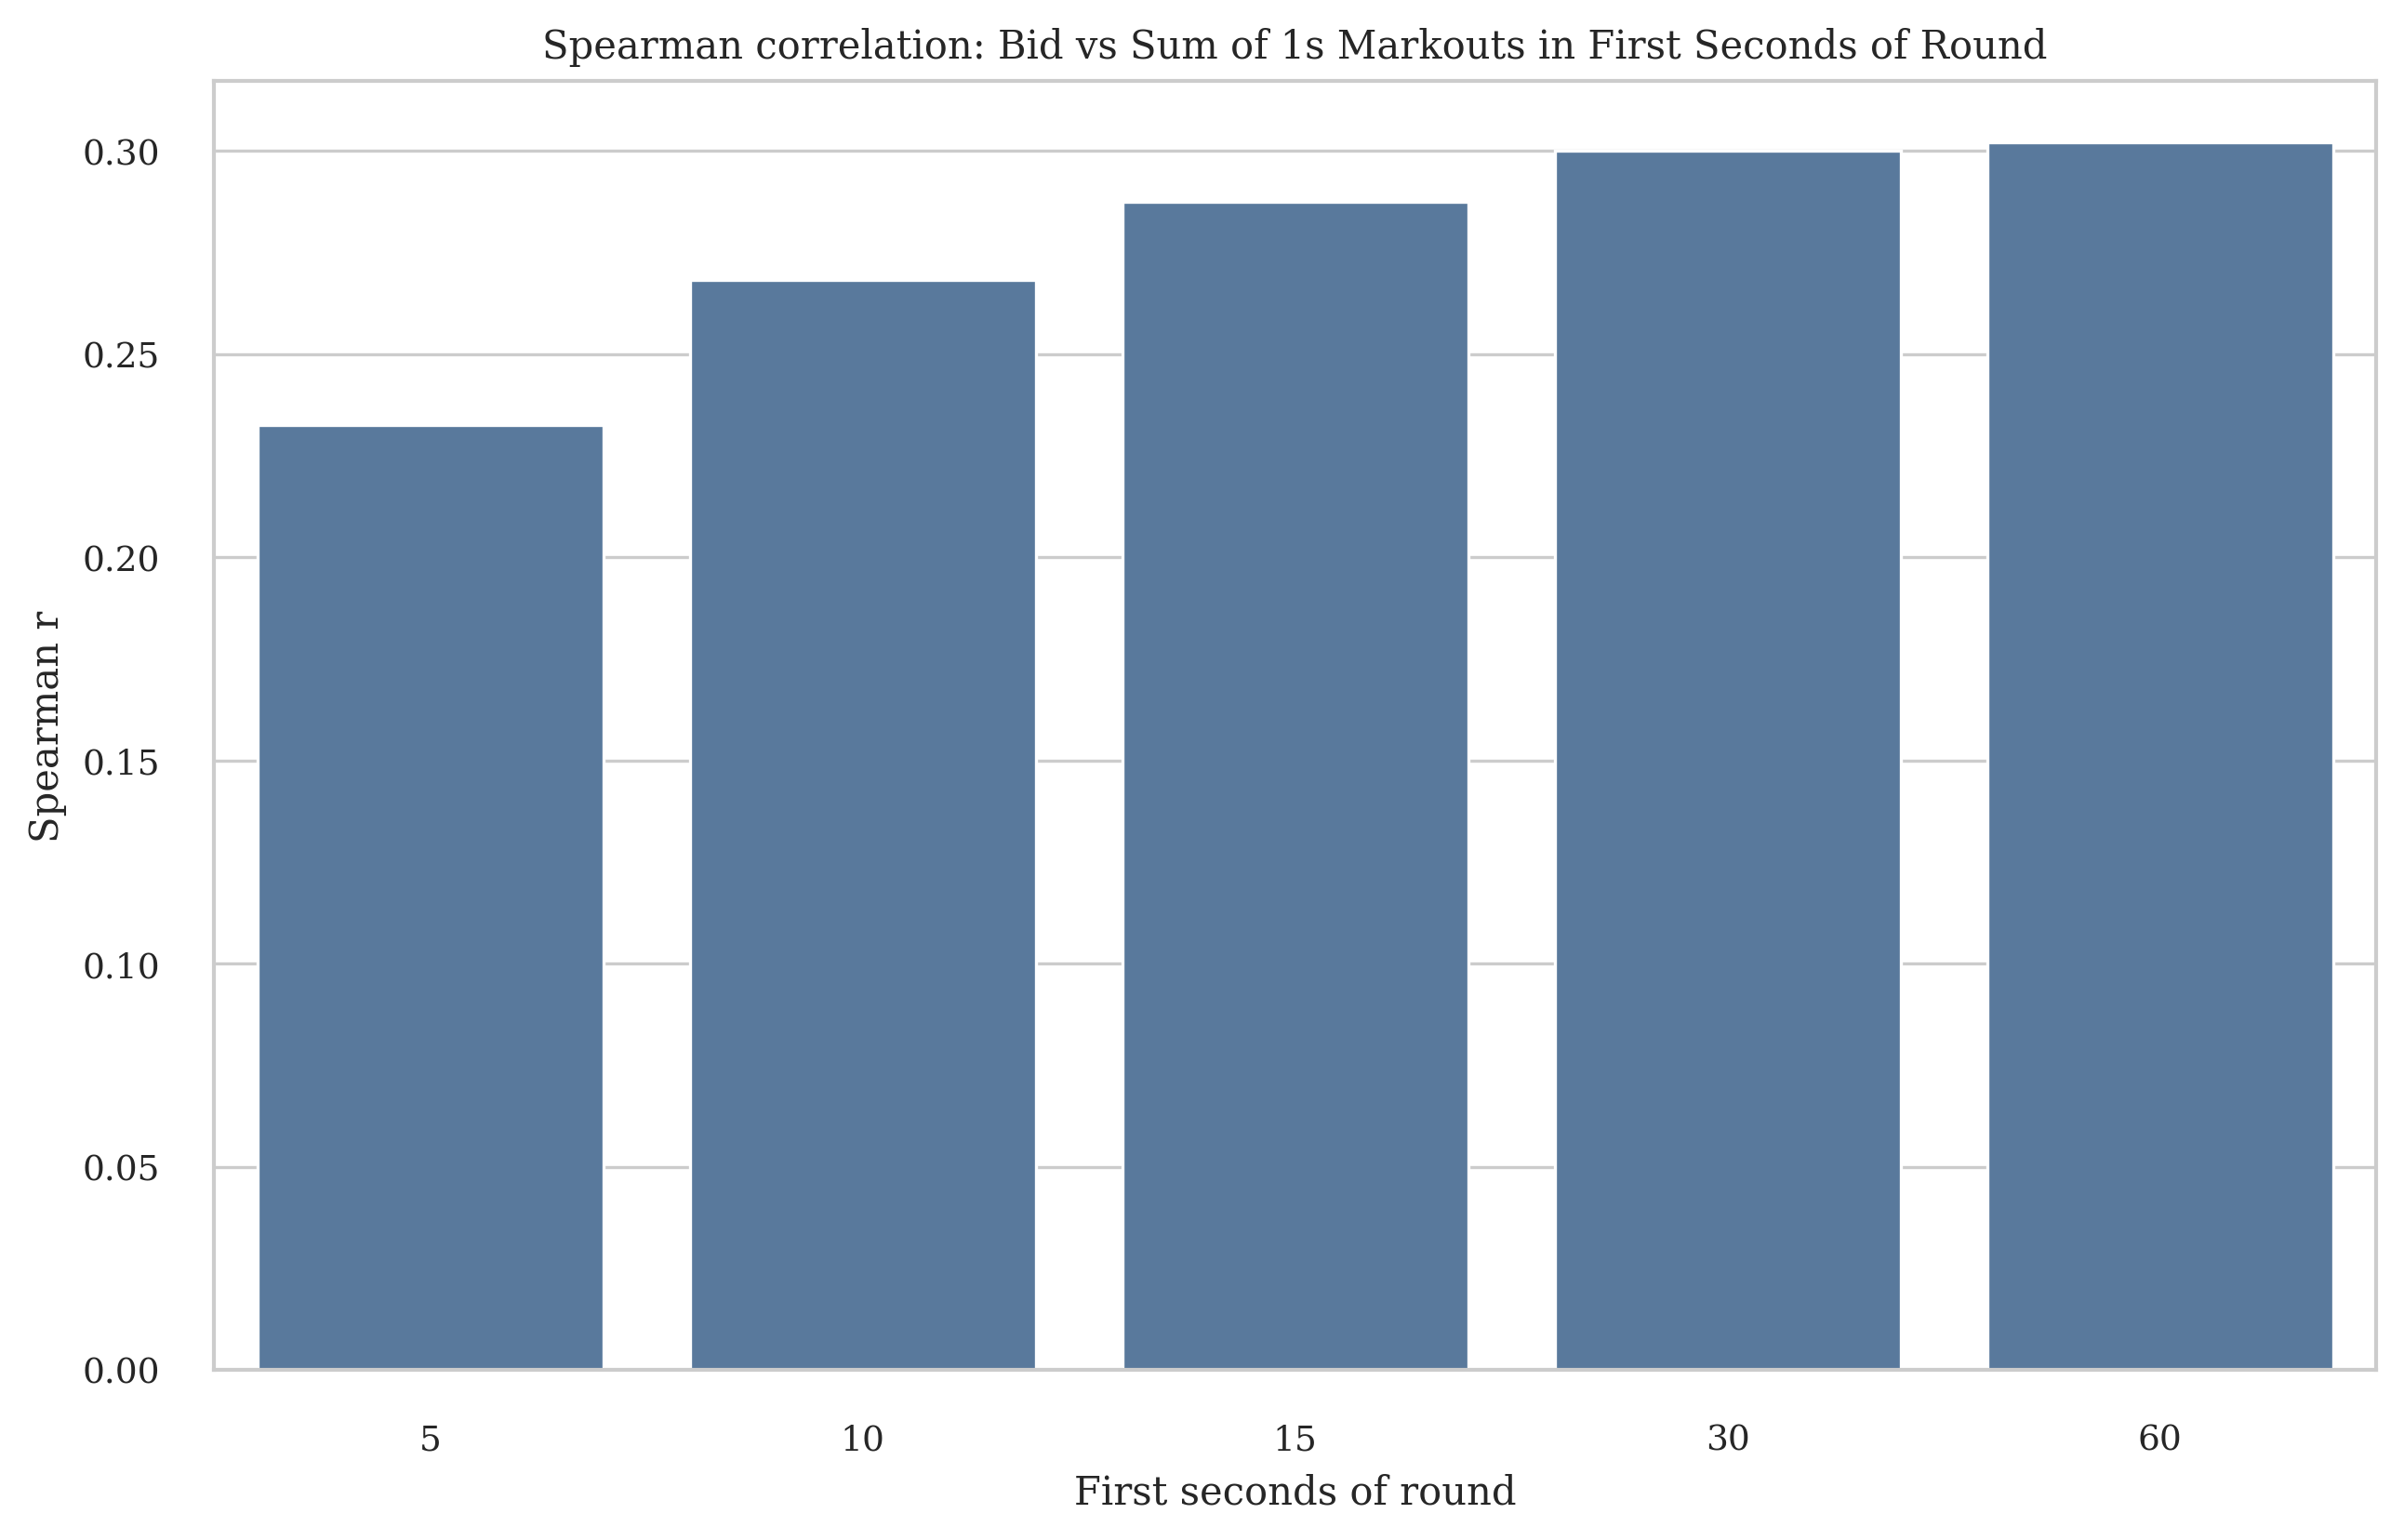

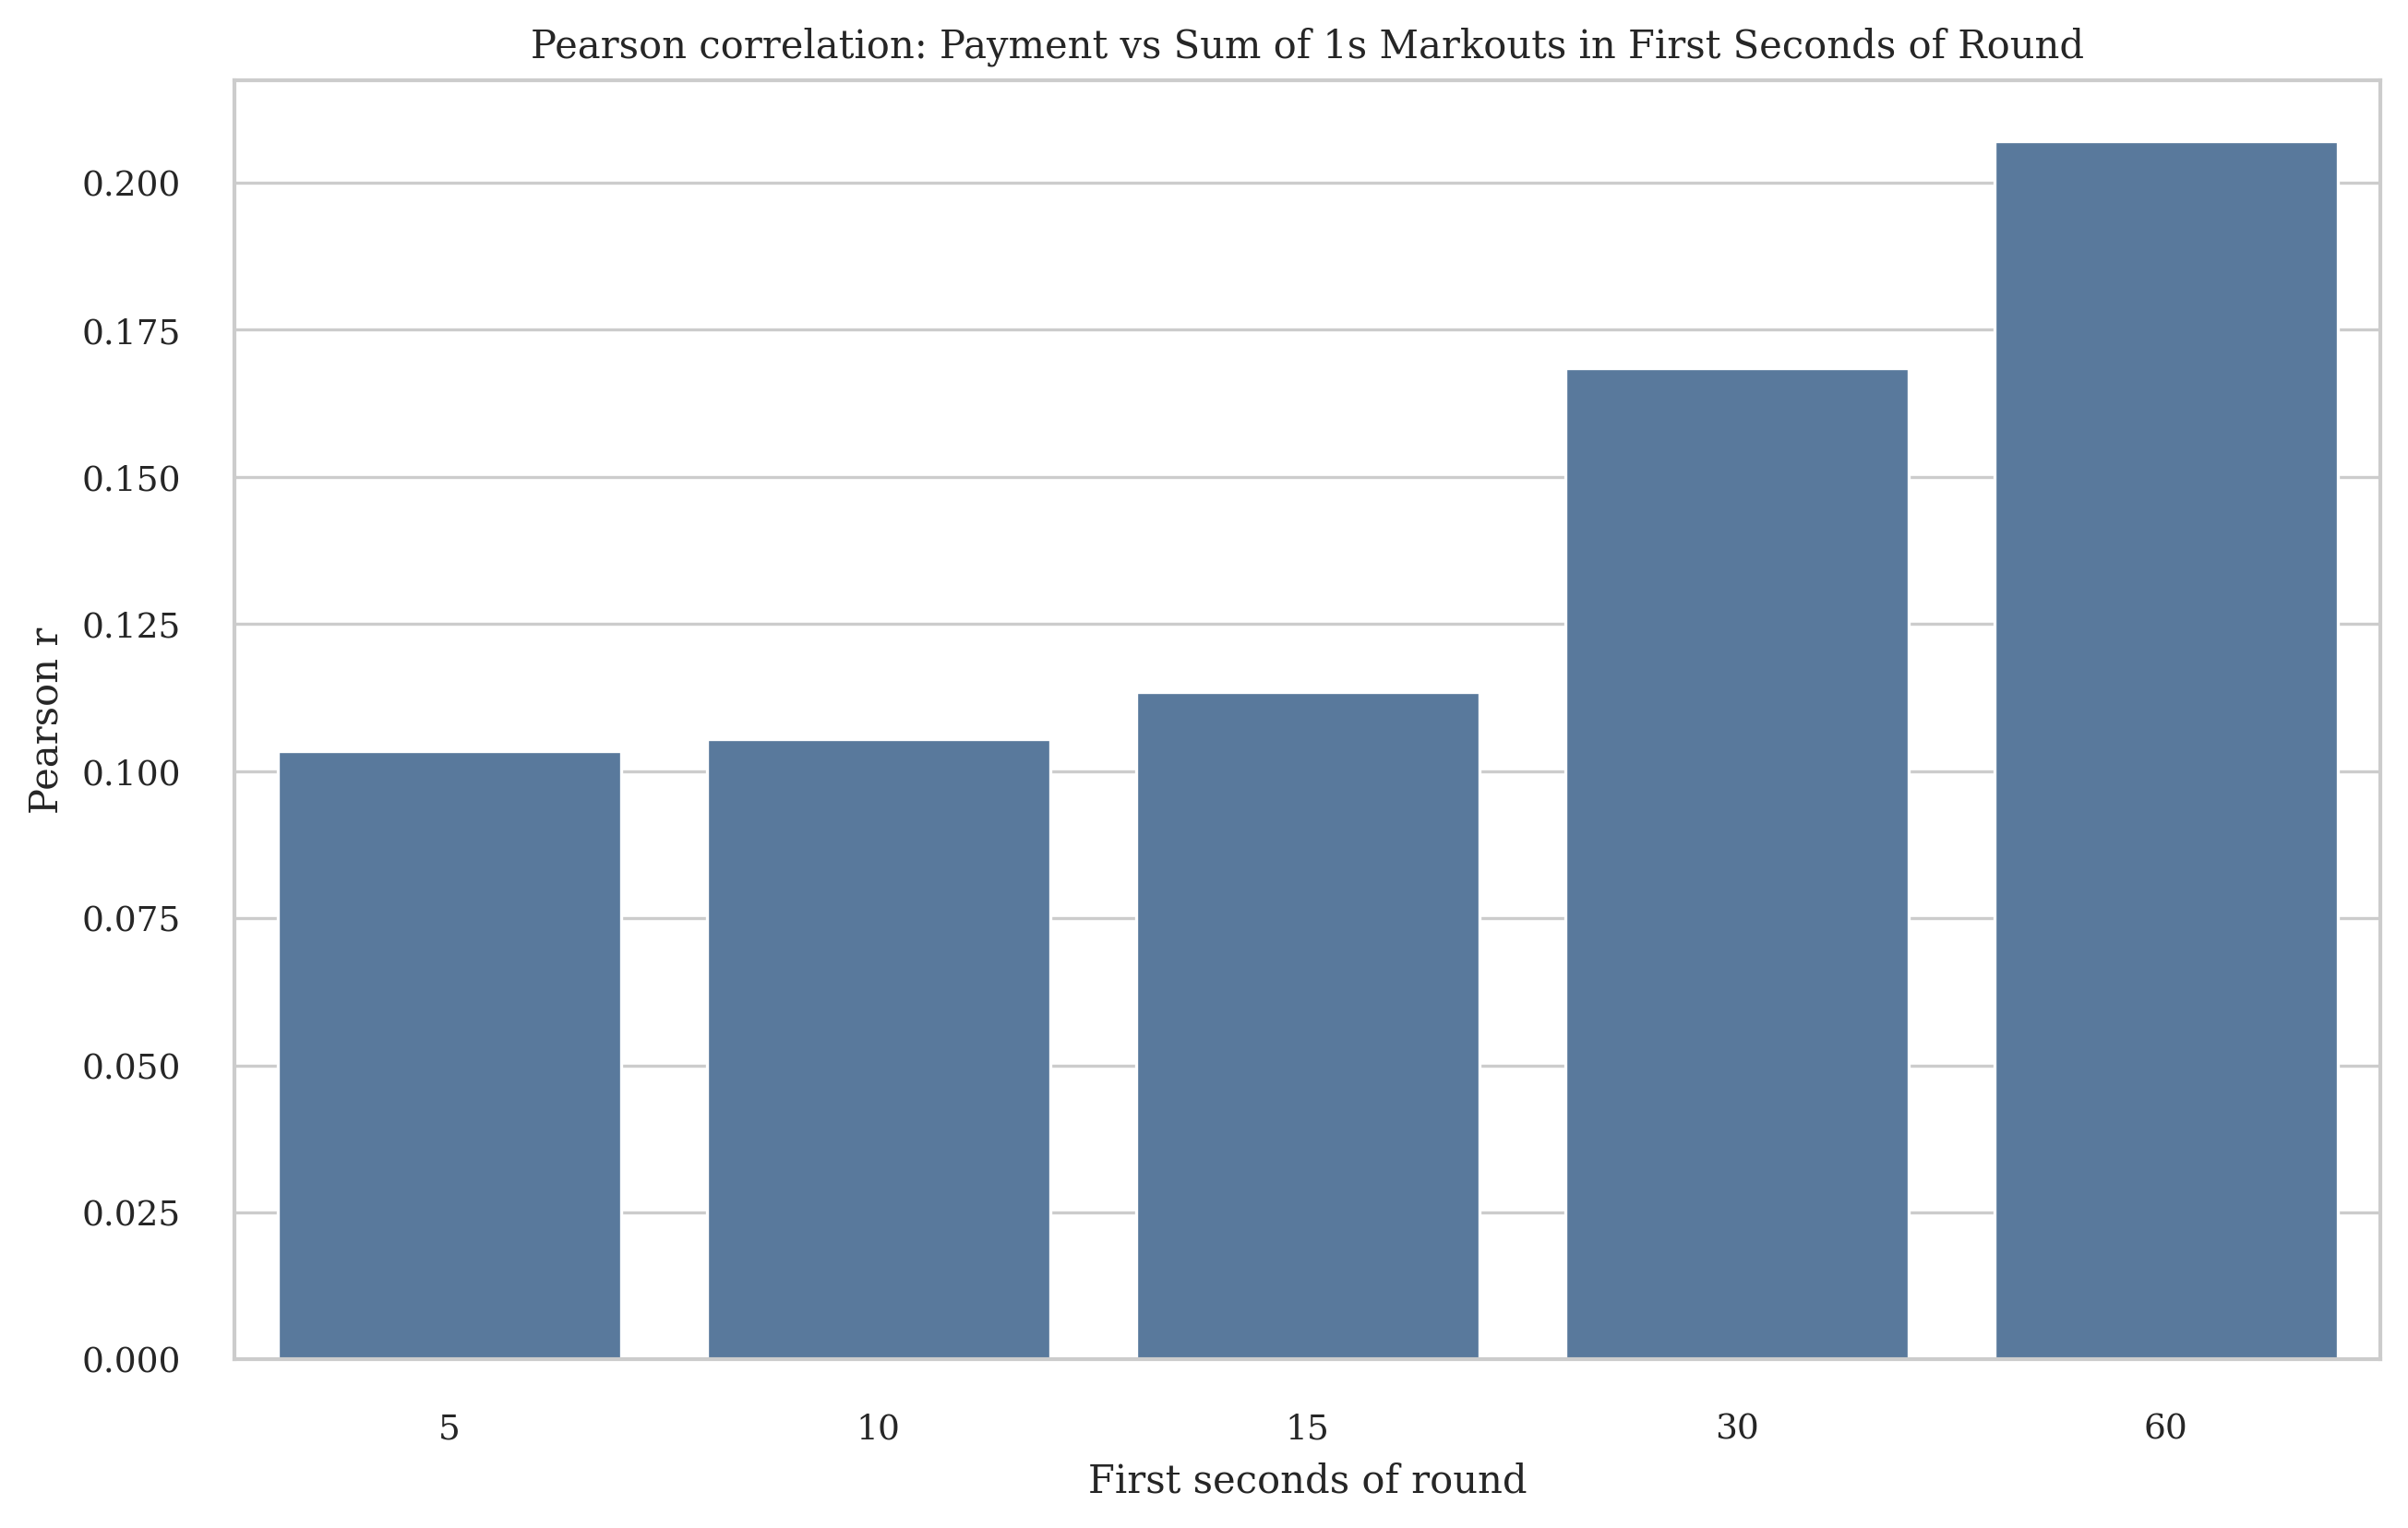

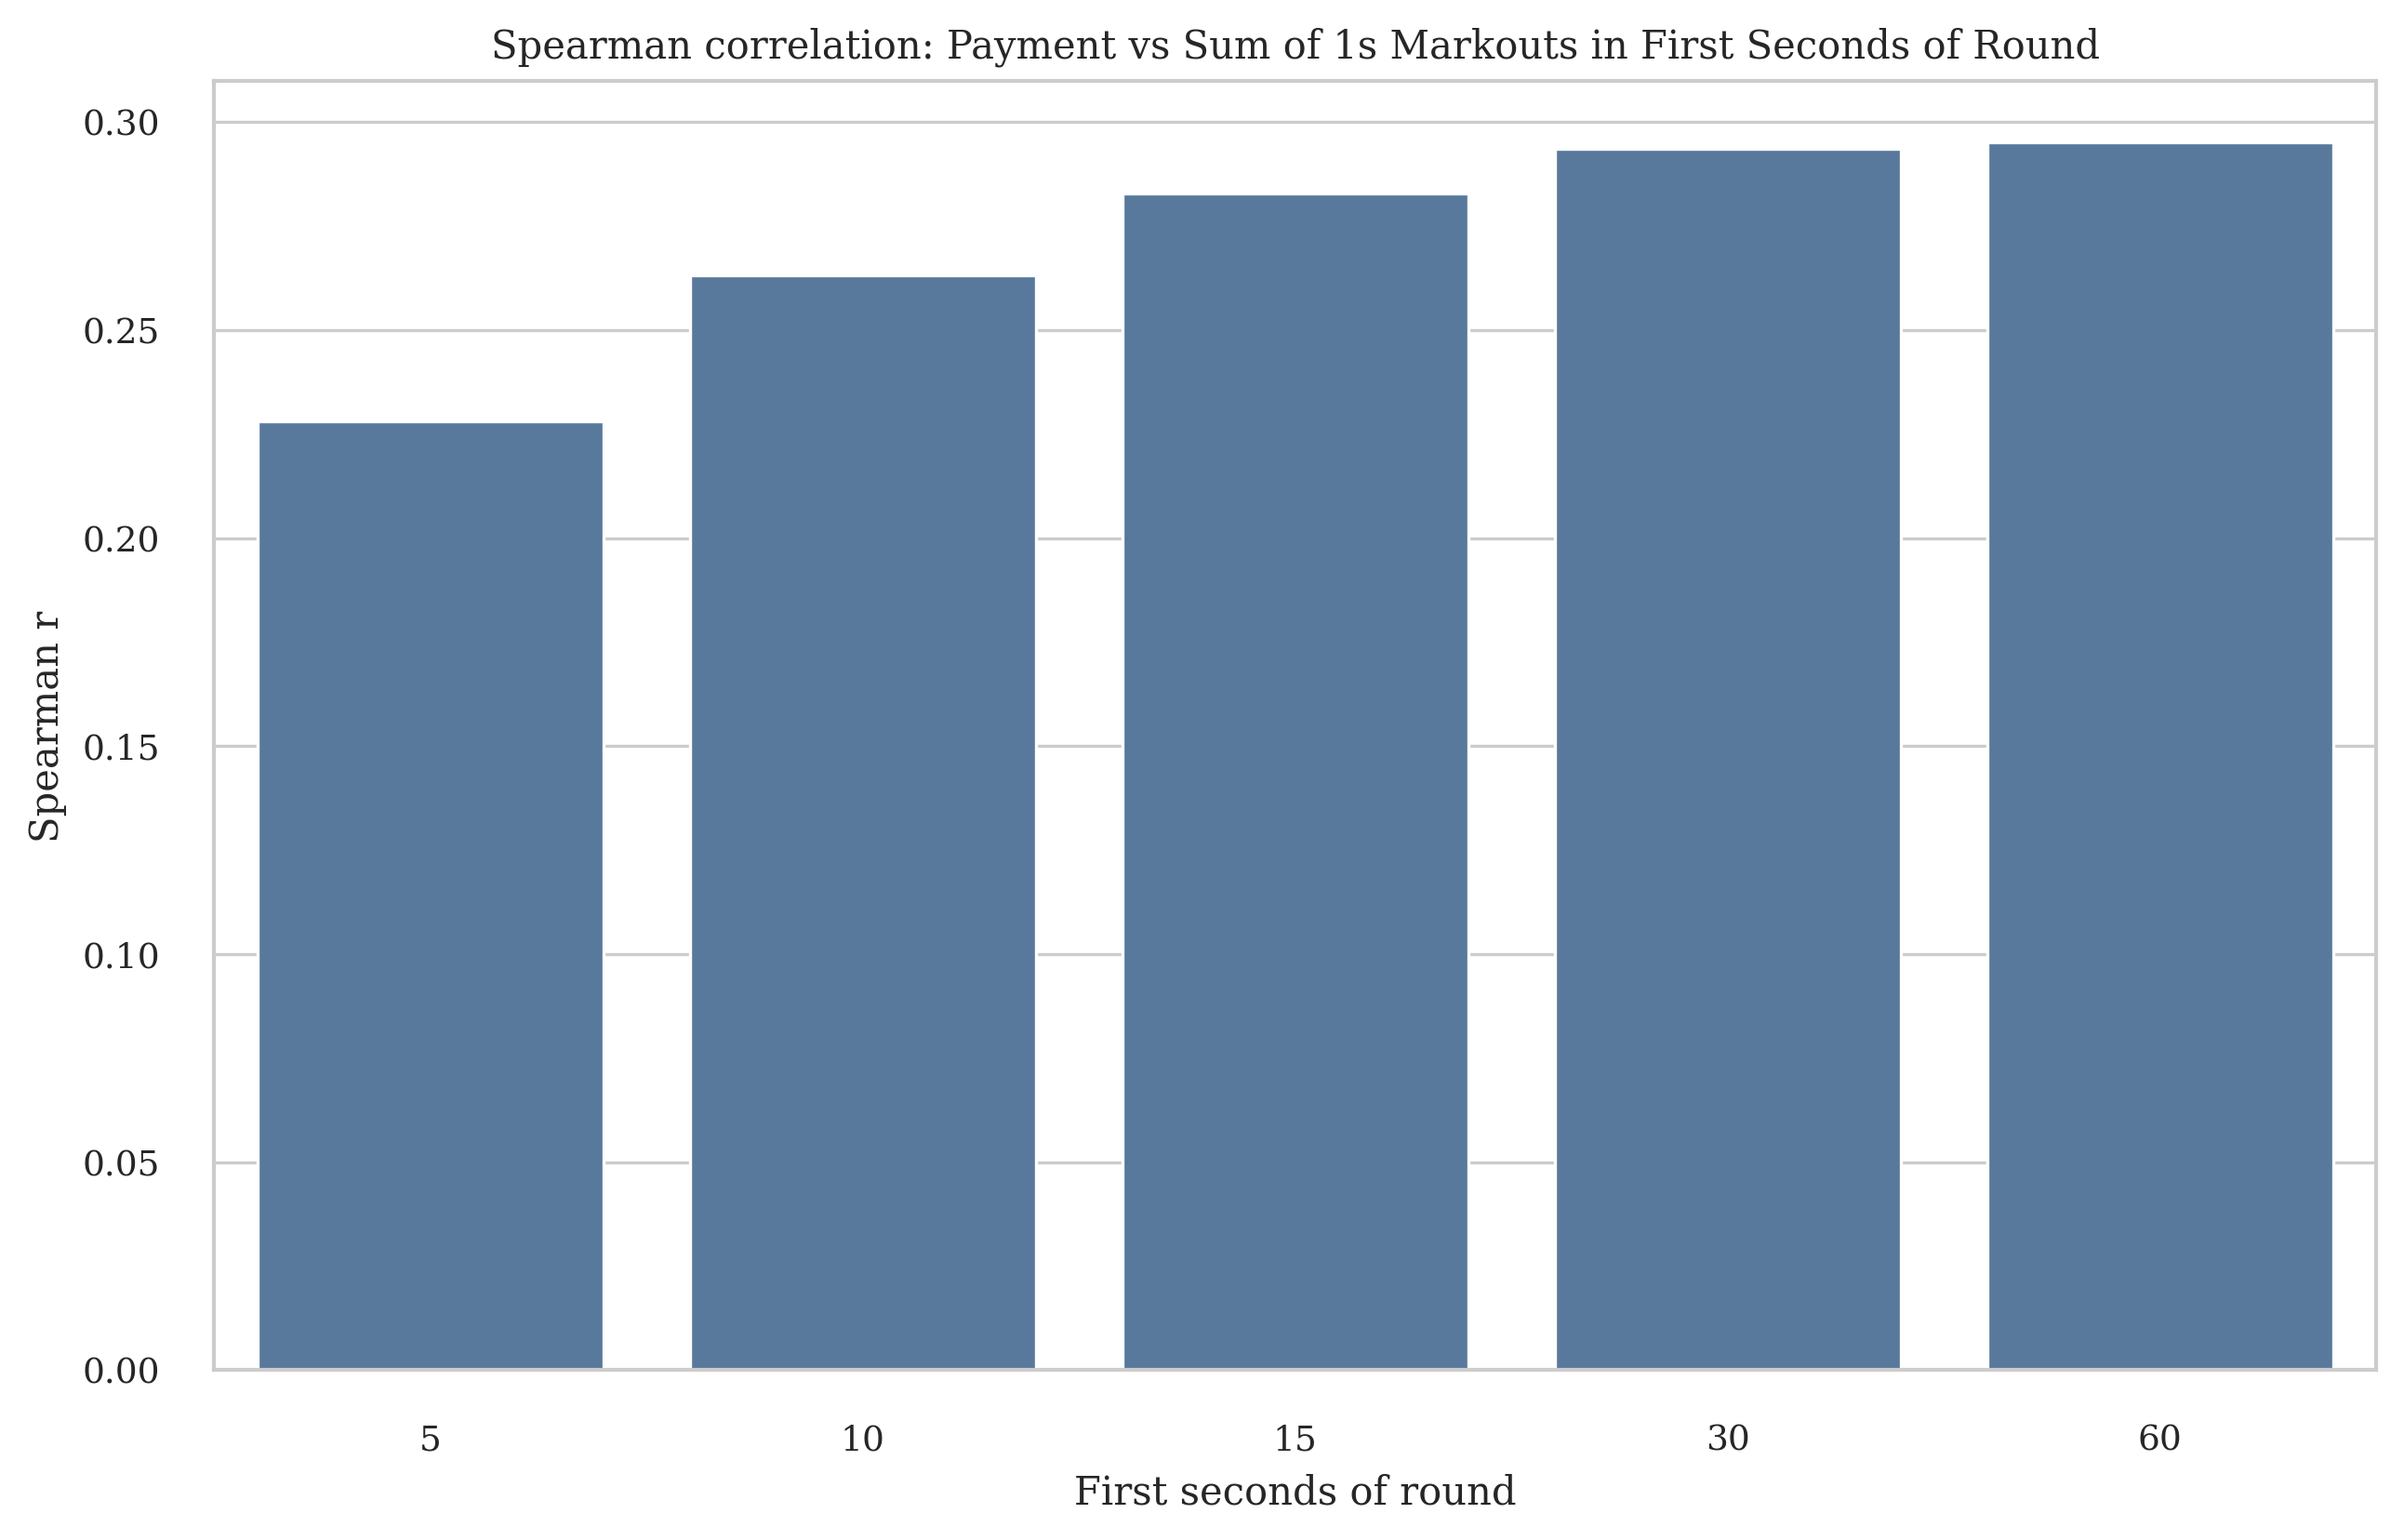

In [8]:
# Figure 3 (updated): Correlation of bid vs. sum of 1s markouts in first X seconds of each round
FIRST_SECONDS = [5, 10, 15, 30, 60]

# Sum 1s markouts of transactions per round within first X seconds
per_round_first = {}
for x_sec in FIRST_SECONDS:
    per_r = (
        txs_in_rounds.filter(pl.col("offset_s") < x_sec)
        .group_by("__row_id__")
        .agg(
            pl.col(f"tx_markout_minus_gas_usd_{H_DEF}s")
            .sum()
            .alias(f"sum_markout_first_{x_sec}s")
        )
    )
    per_round_first[x_sec] = per_r

# Merge into rounds_df
base = rounds_df.select(["__row_id__", "round", "bid_in_usd", "payment_in_usd"])  # ensure row id present
for x_sec in FIRST_SECONDS:
    base = base.join(per_round_first[x_sec], on="__row_id__", how="left")
    base = base.with_columns(pl.col(f"sum_markout_first_{x_sec}s").fill_null(0.0))

# Compute correlations
corr_rows = []
base_pd = base.to_pandas()
for x_sec in FIRST_SECONDS:
    df = base_pd[["bid_in_usd", f"sum_markout_first_{x_sec}s"]].dropna()
    corr = df.corr(numeric_only=True).iloc[0, 1] if len(df) >= 3 else np.nan
    corr_rows.append({"first_seconds": x_sec, "corr": corr})

corr_df = pd.DataFrame(corr_rows)

sns.barplot(data=corr_df, x="first_seconds", y="corr", color="#4e79a7")
plt.title("Correlation: Bid vs Sum of 1s Markouts in First Seconds of Round")
plt.xlabel("First seconds of round")
plt.ylabel("Pearson r")
# Emphasize differences by tightening y-limits around observed range
valid = corr_df["corr"].dropna()
if len(valid) >= 1:
    vmin, vmax = float(valid.min()), float(valid.max())
    if vmin == vmax:
        pad = 0.05 if abs(vmin) < 0.95 else 0.02
        plt.ylim(vmin - pad, vmax + pad)
    else:
        rng = vmax - vmin
        pad = max(0.05, rng * 0.2)
        low = max(-1.0, vmin - pad)
        high = min(1.0, vmax + pad)
        plt.ylim(low, high)
else:
    plt.ylim(-1, 1)
plt.axhline(0, color="black", lw=1)
plt.show()

# figure 3-1: correlation of bid vs. sum of 1s markouts in first X seconds of each round, but with spearman correlation
corr_spearman_rows = []
base_pd = base.to_pandas()
for x_sec in FIRST_SECONDS:
    df = base_pd[["bid_in_usd", f"sum_markout_first_{x_sec}s"]].dropna()
    corr = df.corr(numeric_only=True, method="spearman").iloc[0, 1] if len(df) >= 3 else np.nan
    corr_spearman_rows.append({"first_seconds": x_sec, "corr": corr})

corr_spearman_df = pd.DataFrame(corr_spearman_rows)

# plot the spearman correlation
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_spearman_df, x="first_seconds", y="corr", color="#4e79a7")
plt.title("Spearman correlation: Bid vs Sum of 1s Markouts in First Seconds of Round")
plt.xlabel("First seconds of round")
plt.ylabel("Spearman r")
plt.show()

# figure 3-2: correlation of payment vs. sum of 1s markouts in first X seconds of each round, but with pearson correlation
corr_pearson_rows = []
base_pd = base.to_pandas()
for x_sec in FIRST_SECONDS:
    df = base_pd[["payment_in_usd", f"sum_markout_first_{x_sec}s"]].dropna()
    corr = df.corr(numeric_only=True, method="pearson").iloc[0, 1] if len(df) >= 3 else np.nan
    corr_pearson_rows.append({"first_seconds": x_sec, "corr": corr})

corr_pearson_df = pd.DataFrame(corr_pearson_rows)

# plot the pearson correlation
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_pearson_df, x="first_seconds", y="corr", color="#4e79a7")
plt.title("Pearson correlation: Payment vs Sum of 1s Markouts in First Seconds of Round")
plt.xlabel("First seconds of round")
plt.ylabel("Pearson r")
plt.show()

# figure 3-3: correlation of payment vs. sum of 1s markouts in first X seconds of each round, but with spearman correlation
corr_spearman_rows = []
base_pd = base.to_pandas()
for x_sec in FIRST_SECONDS:
    df = base_pd[["payment_in_usd", f"sum_markout_first_{x_sec}s"]].dropna()
    corr = df.corr(numeric_only=True, method="spearman").iloc[0, 1] if len(df) >= 3 else np.nan
    corr_spearman_rows.append({"first_seconds": x_sec, "corr": corr})

corr_spearman_df = pd.DataFrame(corr_spearman_rows)

# plot the spearman correlation
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_spearman_df, x="first_seconds", y="corr", color="#4e79a7")
plt.title("Spearman correlation: Payment vs Sum of 1s Markouts in First Seconds of Round")
plt.xlabel("First seconds of round")
plt.ylabel("Spearman r")
plt.show()

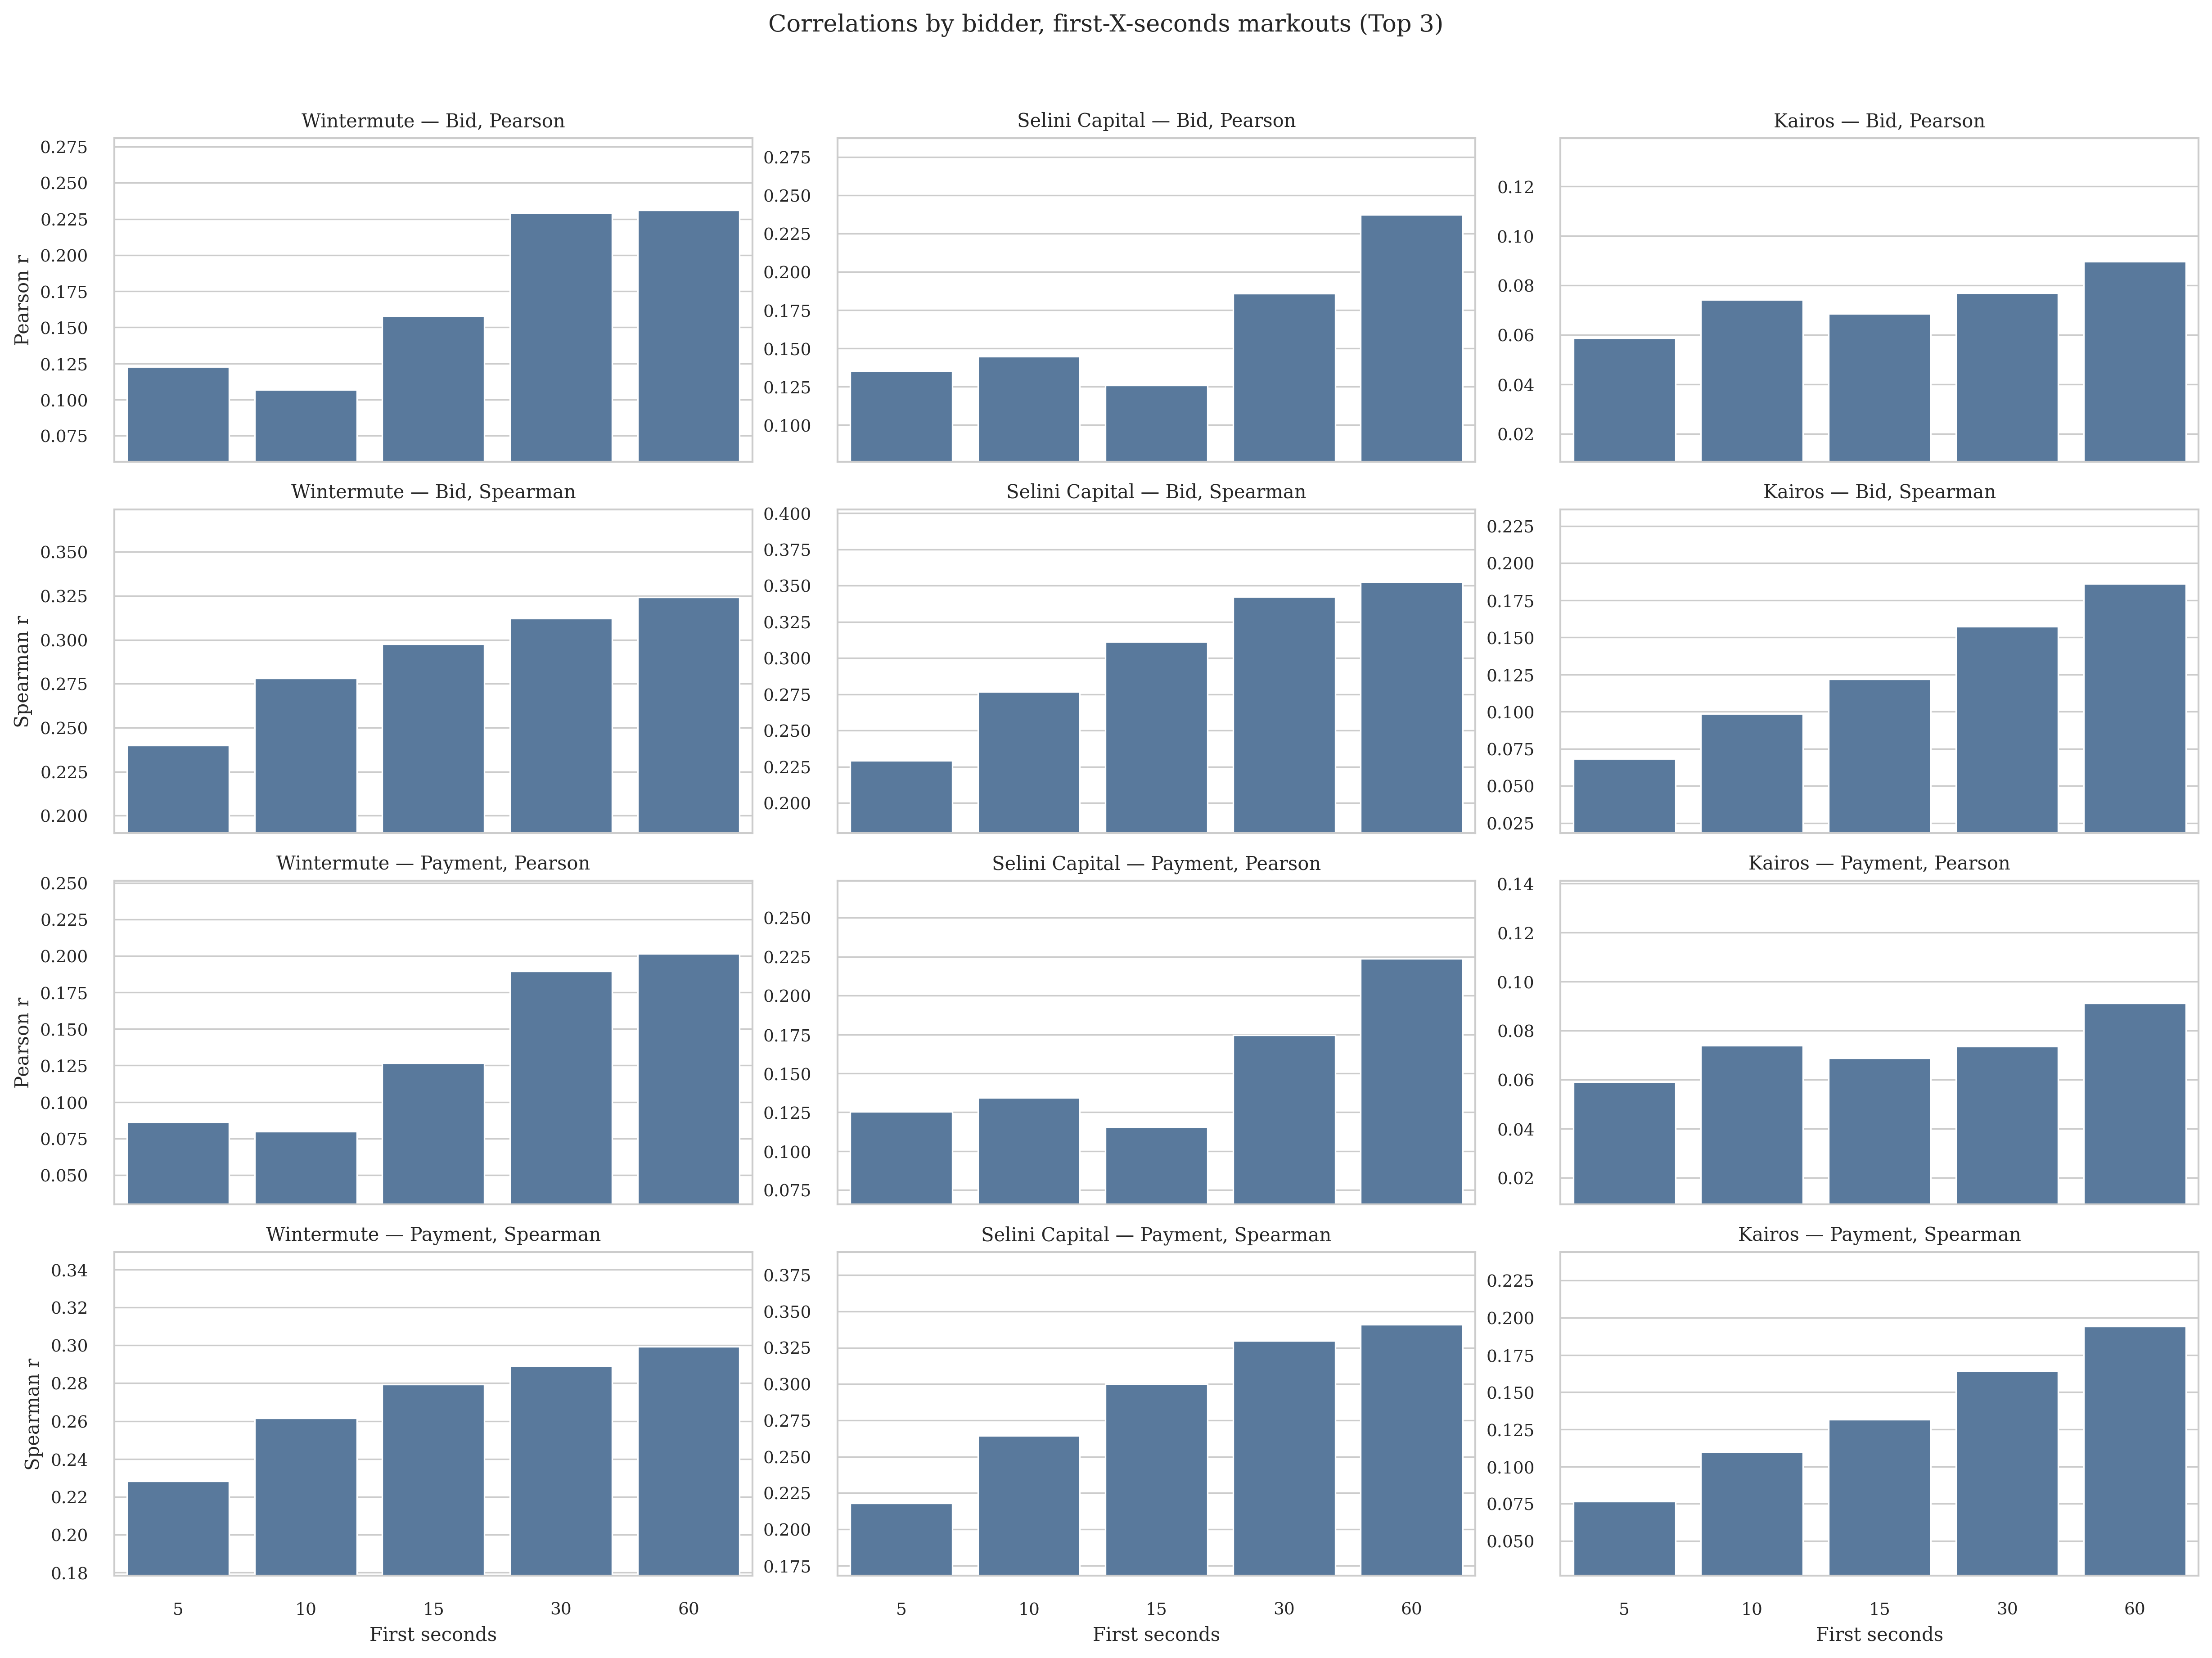

In [9]:
# figure 3-a: Correlations per Top 3 bidder (Pearson & Spearman)
# - For each of the Top 3 bidders, compute correlations between
#   {bid_in_usd, payment_in_usd} and sum of 1s markouts within the first X seconds
#   using both Pearson and Spearman methods.

# Ensure FIRST_SECONDS exists (reuse from earlier if present)
try:
    FIRST_SECONDS
except NameError:
    FIRST_SECONDS = [5, 10, 15, 30, 60]

# Determine Top 3 bidders by total bid_in_usd
rounds_pd = rounds_df.to_pandas()
_top3 = (
    rounds_pd.groupby("first_price_bidder")["bid_in_usd"].sum().nlargest(3).index.tolist()
)
# Friendly names by rank order
_friendly = {}
if len(_top3) > 0:
    _friendly[_top3[0]] = "Wintermute"
if len(_top3) > 1:
    _friendly[_top3[1]] = "Selini Capital"
if len(_top3) > 2:
    _friendly[_top3[2]] = "Kairos"

# Build per-round sums for first X seconds (reuse precomputed txs_in_rounds)
per_round_first = {}
for x_sec in FIRST_SECONDS:
    per_r = (
        txs_in_rounds.filter(pl.col("offset_s") < x_sec)
        .group_by("__row_id__")
        .agg(
            pl.col(f"tx_markout_minus_gas_usd_{H_DEF}s").sum().alias(f"sum_markout_first_{x_sec}s")
        )
    )
    per_round_first[x_sec] = per_r

# Base table with bidder metadata
base = rounds_df.select(["__row_id__", "first_price_bidder", "bid_in_usd", "payment_in_usd"])
for x_sec in FIRST_SECONDS:
    base = base.join(per_round_first[x_sec], on="__row_id__", how="left")
    base = base.with_columns(pl.col(f"sum_markout_first_{x_sec}s").fill_null(0.0))

# Compute correlations per bidder and method into a tidy DataFrame
rows = []
base_pd = base.to_pandas()
for bidder in _top3:
    bdf = base_pd[base_pd["first_price_bidder"] == bidder].copy()
    for metric in ["bid_in_usd", "payment_in_usd"]:
        for method in ["pearson", "spearman"]:
            for x_sec in FIRST_SECONDS:
                col = f"sum_markout_first_{x_sec}s"
                df_local = bdf[[metric, col]].dropna()
                if len(df_local) >= 3 and df_local[metric].std() > 0 and df_local[col].std() > 0:
                    r = df_local.corr(numeric_only=True, method=method).iloc[0, 1]
                else:
                    r = np.nan
                rows.append(
                    {
                        "first_price_bidder": bidder,
                        "metric": metric,
                        "method": method,
                        "first_seconds": x_sec,
                        "corr": r,
                    }
                )

corr_by_bidder = pd.DataFrame(rows)
# Add friendly names
corr_by_bidder["bidder_name"] = corr_by_bidder["first_price_bidder"].map(_friendly).fillna(corr_by_bidder["first_price_bidder"])
# corr_by_bidder columns:
#   ["first_price_bidder" (str), "bidder_name" (str), "metric" ("bid_in_usd"|"payment_in_usd"),
#    "method" ("pearson"|"spearman"), "first_seconds" (int), "corr" (float)]

# Plot 12 subplots: 3 bidders x 2 metrics x 2 methods
combos = [("bid_in_usd", "pearson"), ("bid_in_usd", "spearman"), ("payment_in_usd", "pearson"), ("payment_in_usd", "spearman")]
metric_titles = {"bid_in_usd": "Bid", "payment_in_usd": "Payment"}
method_titles = {"pearson": "Pearson", "spearman": "Spearman"}

n_rows = len(combos)
n_cols = len(_top3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.0 * n_rows), sharex=True)

for col_idx, bidder in enumerate(_top3):
    name = _friendly.get(bidder, bidder)
    for row_idx, (metric, method) in enumerate(combos):
        ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
        sel = corr_by_bidder[
            (corr_by_bidder["first_price_bidder"] == bidder)
            & (corr_by_bidder["metric"] == metric)
            & (corr_by_bidder["method"] == method)
        ].copy()
        # Ensure ordering by FIRST_SECONDS
        sel = sel.sort_values("first_seconds")
        sns.barplot(data=sel, x="first_seconds", y="corr", color="#4e79a7", ax=ax)
        # Title and labels
        ax.set_title(f"{name} — {metric_titles[metric]}, {method_titles[method]}")
        if col_idx == 0:
            ax.set_ylabel(f"{method_titles[method]} r")
        else:
            ax.set_ylabel("")
        if row_idx == n_rows - 1:
            ax.set_xlabel("First seconds")
        else:
            ax.set_xlabel("")
        ax.axhline(0, color="black", lw=1)
        # Tight y-limits around data if available
        valid = sel["corr"].dropna()
        if len(valid) >= 1:
            vmin, vmax = float(valid.min()), float(valid.max())
            if vmin == vmax:
                pad = 0.05 if abs(vmin) < 0.95 else 0.02
                ax.set_ylim(vmin - pad, vmax + pad)
            else:
                rng = vmax - vmin
                pad = max(0.05, rng * 0.2)
                low = max(-1.0, vmin - pad)
                high = min(1.0, vmax + pad)
                ax.set_ylim(low, high)
        else:
            ax.set_ylim(-1, 1)

fig.suptitle("Correlations by bidder, first-X-seconds markouts (Top 3)", y=1.02)
plt.tight_layout()
plt.show()

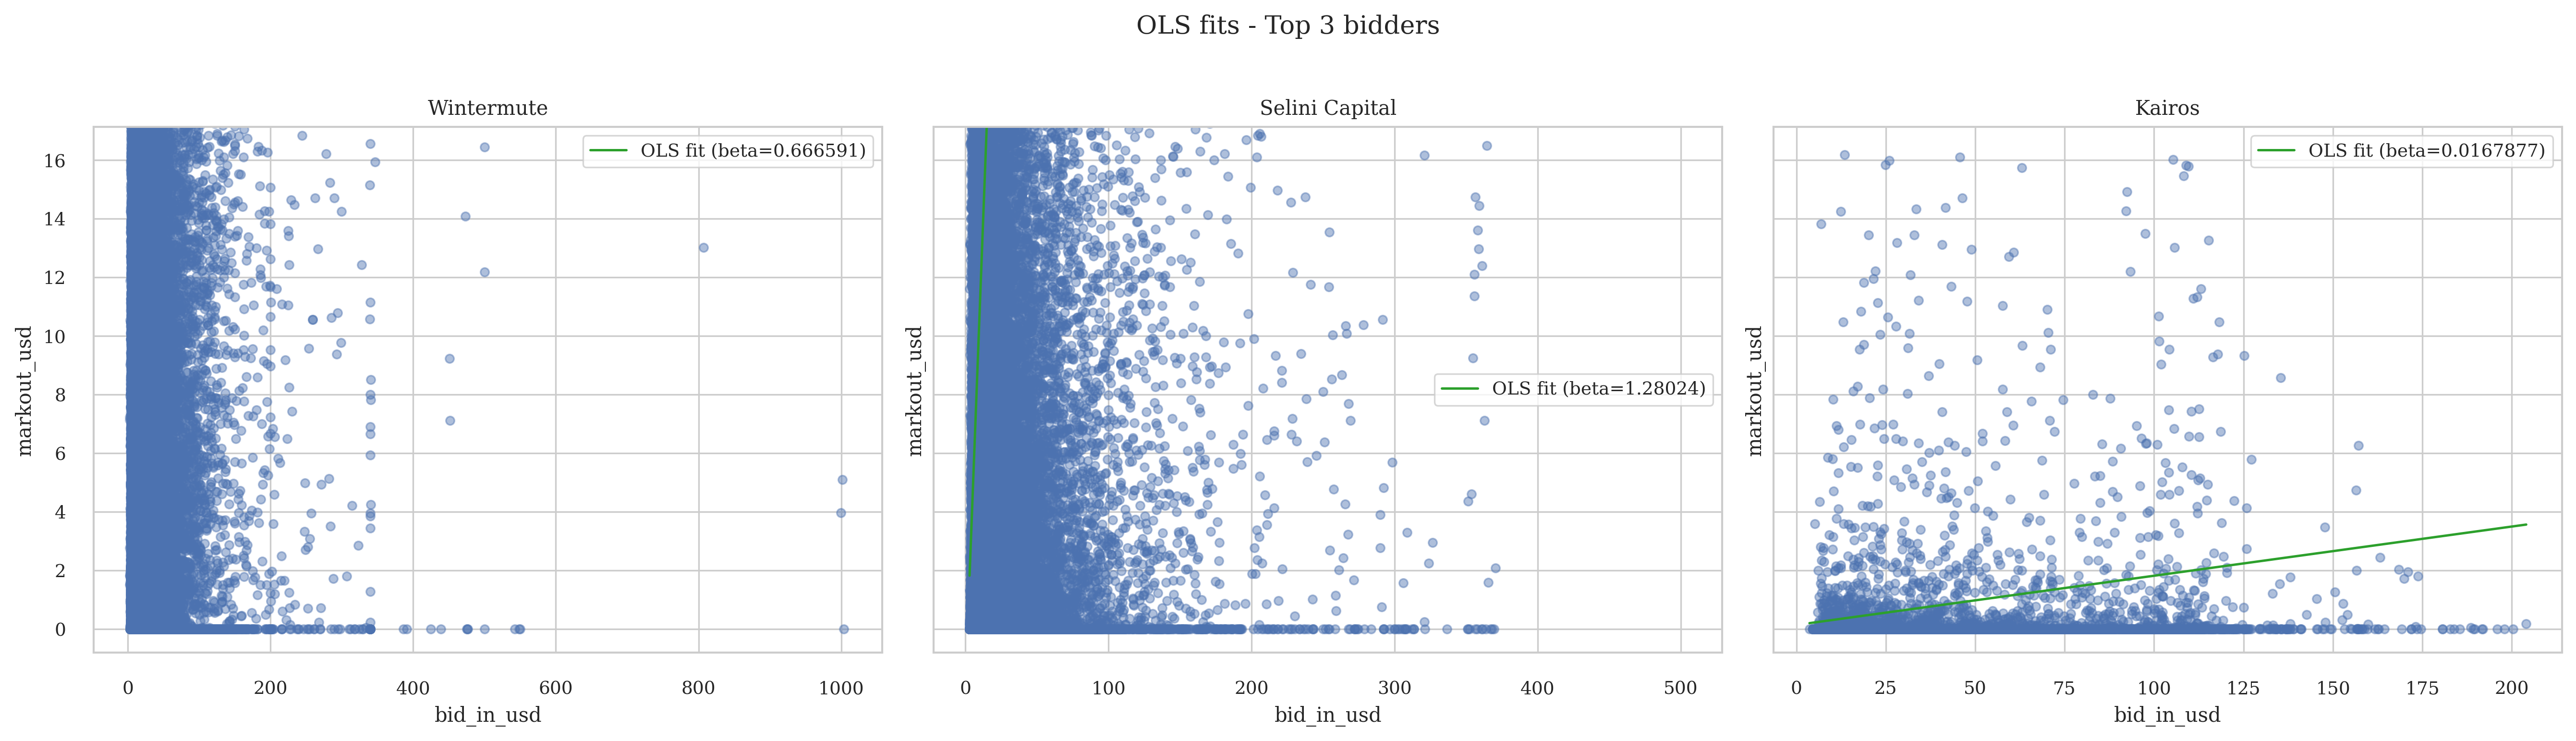

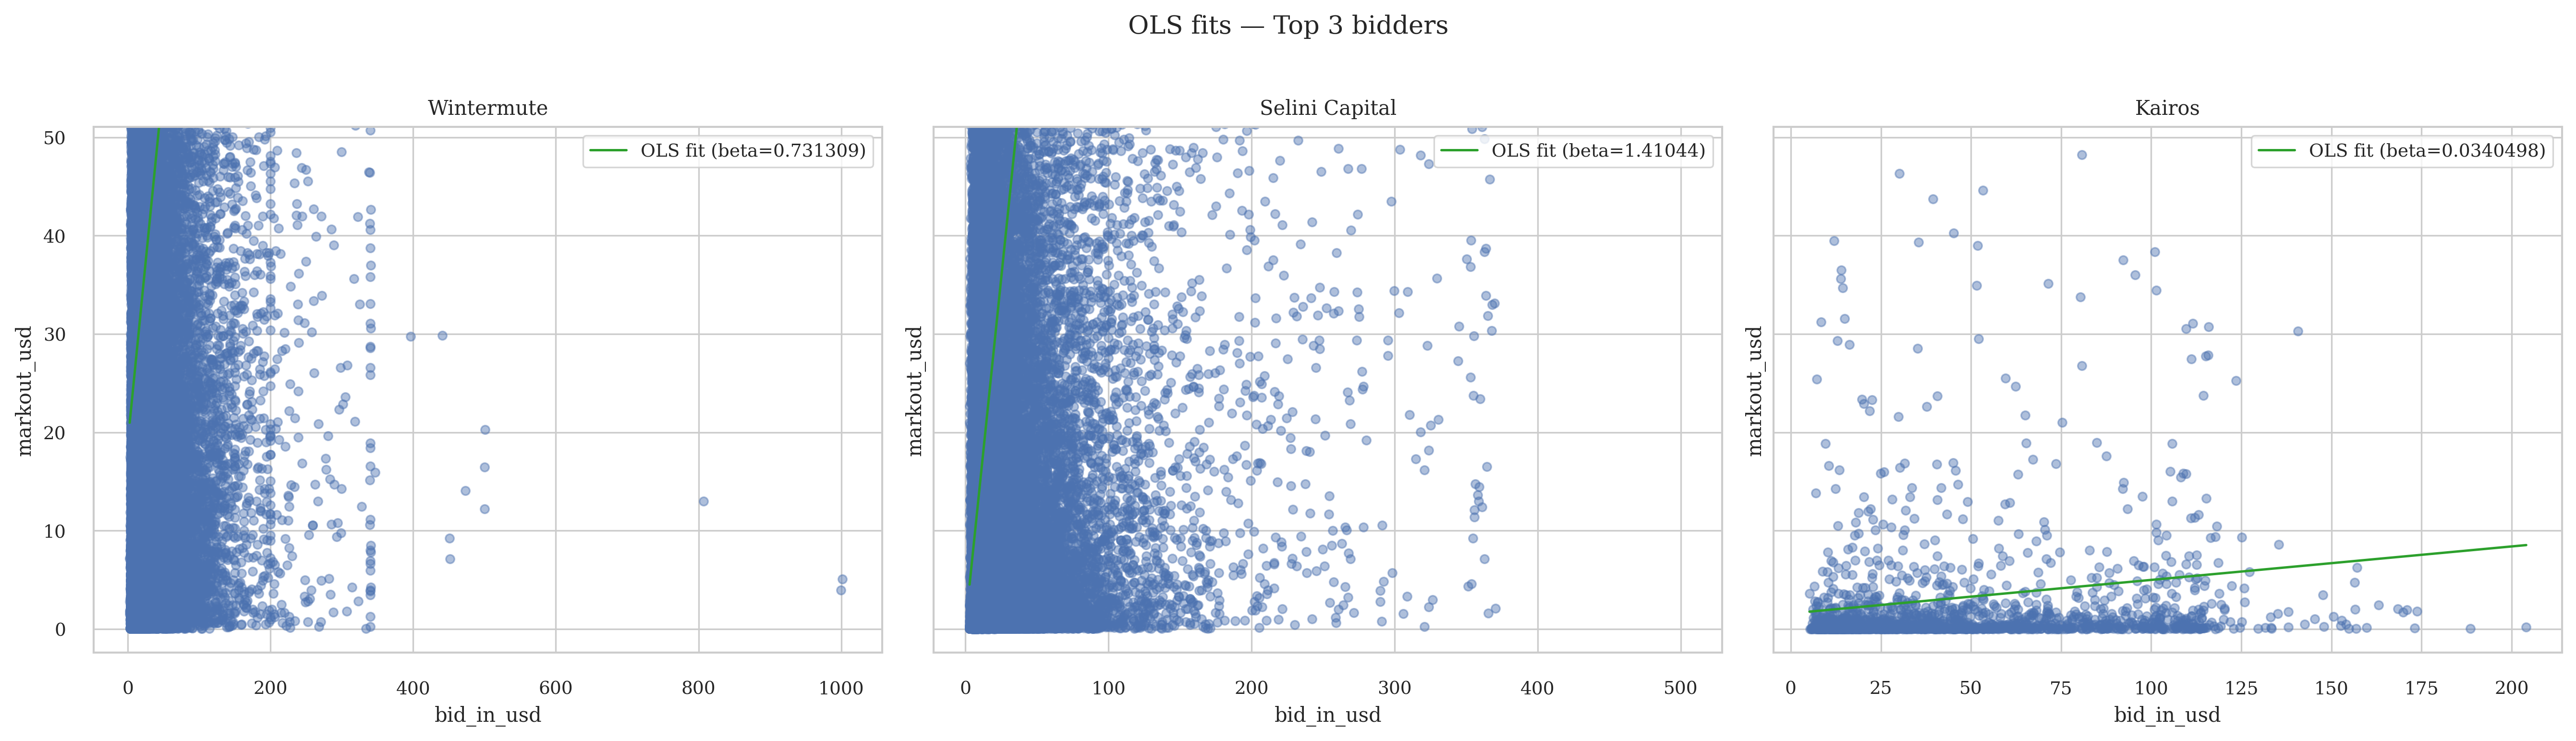

In [10]:
# figure 4: OLS summary grids (1s) - two figures with 3 subplots each (Top3 bidders)
H_TOP = 1

rounds_pd = rounds_df.to_pandas()
_top3 = (
    rounds_pd.groupby("first_price_bidder")["bid_in_usd"]
    .sum()
    .nlargest(3)
    .index.tolist()
)
# Friendly names for entities in rank order
_friendly = {}
if len(_top3) > 0:
    _friendly[_top3[0]] = "Wintermute"
if len(_top3) > 1:
    _friendly[_top3[1]] = "Selini Capital"
if len(_top3) > 2:
    _friendly[_top3[2]] = "Kairos"
# Prepare datasets for all vs positive-only
all_sel = (
    rounds_pd[rounds_pd["first_price_bidder"].isin(_top3)]
    .copy()
    .rename(columns={f"agg_markout_{H_TOP}s": "markout_usd"})
)
pos_sel = all_sel[all_sel["markout_usd"] > 0].copy()

# Figure: All rounds (Top3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, bidder in enumerate(_top3):
    dfa = all_sel[all_sel["first_price_bidder"] == bidder].dropna(
        subset=["bid_in_usd", "markout_usd"]
    )
    _draw_ols(axes[i], dfa, f"{_friendly[bidder]}", "#2ca02c")
fig.suptitle("OLS fits - Top 3 bidders", y=1.02)
plt.tight_layout()
plt.show()

# Figure: Positive-only rounds (Top3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, bidder in enumerate(_top3):
    dfp = pos_sel[pos_sel["first_price_bidder"] == bidder].dropna(
        subset=["bid_in_usd", "markout_usd"]
    )
    _draw_ols(axes[i], dfp, f"{_friendly[bidder]}", "#2ca02c")
fig.suptitle("OLS fits — Top 3 bidders", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Core statistics tables (printed via tabulate)
# Uses existing objects from previous cells: rounds_df, per_tx_mapped_1s, txs_in_rounds,
# swaps_mo_1s_tmp, prices_all, ar_sorted, H_DEF, and FIRST_SECONDS if needed.

import pandas as pd
import numpy as np
from tabulate import tabulate

# ---------- Helpers ----------

def _friendly_map_from_top3(rounds_pl: pl.DataFrame) -> tuple[list[str], dict]:
    top3 = (
        rounds_pl.group_by("first_price_bidder")
        .agg(pl.col("bid_in_usd").sum().alias("sum_bid"))
        .sort("sum_bid", descending=True)
        .select("first_price_bidder")
        .head(3)["first_price_bidder"].to_list()
    )
    friendly = {}
    if len(top3) > 0:
        friendly[top3[0]] = "Wintermute"
    if len(top3) > 1:
        friendly[top3[1]] = "Selini Capital"
    if len(top3) > 2:
        friendly[top3[2]] = "Kairos"
    return top3, friendly


def _per_round_sum(source_txs: pl.DataFrame, window_s: int) -> pl.DataFrame:
    col = f"tx_markout_minus_gas_usd_{H_DEF}s"
    return (
        source_txs.filter(pl.col("offset_s") < window_s)
        .group_by("__row_id__")
        .agg(pl.col(col).sum().alias(f"sum_markout_first_{window_s}s"))
    )


def _corr_table(base_pl: pl.DataFrame, window_s: int, bidders: list[str], friendly: dict) -> pd.DataFrame:
    col = f"sum_markout_first_{window_s}s"
    df = base_pl.to_pandas()
    rows = []
    for bidder in bidders:
        d = df[df["first_price_bidder"] == bidder][["bid_in_usd", "payment_in_usd", col]].dropna()
        def safe_corr(x_col: str, method: str) -> float:
            sub = d[[x_col, col]].dropna()
            if len(sub) >= 3 and sub[x_col].std() > 0 and sub[col].std() > 0:
                return float(sub.corr(numeric_only=True, method=method).iloc[0, 1])
            return np.nan
        rows.append(
            {
                "bidder": friendly.get(bidder, bidder),
                "pearson_bid": safe_corr("bid_in_usd", "pearson"),
                "pearson_payment": safe_corr("payment_in_usd", "pearson"),
                "spearman_bid": safe_corr("bid_in_usd", "spearman"),
                "spearman_payment": safe_corr("payment_in_usd", "spearman"),
            }
        )
    return pd.DataFrame(rows)


# ---------- Build ALL-transactions view (temporarily disable positive-only filter) ----------
prev_flag = tx_positive_only
try:
    tx_positive_only = False
    per_tx_1s_all = compute_per_tx_markout_minus_gas(swaps_mo_1s_tmp, prices_all, H_DEF)
    per_tx_mapped_1s_all = (
        per_tx_1s_all.sort("tx_timestamp")
        .join_asof(
            ar_sorted,
            left_on="tx_timestamp",
            right_on="round_start_timestamp",
            strategy="backward",
        )
        .filter(pl.col("tx_timestamp") <= pl.col("round_end_timestamp"))
    )
    txs_in_rounds_all = (
        per_tx_mapped_1s_all
        .with_columns((pl.col("tx_timestamp") - pl.col("round_start_timestamp")).mod(60).alias("offset_s"))
        .select(["__row_id__", "offset_s", f"tx_markout_minus_gas_usd_{H_DEF}s"])
    )
finally:
    tx_positive_only = prev_flag

# ---------- Top3 and friendly names ----------
_top3, _friendly = _friendly_map_from_top3(rounds_df)

# ---------- Bases for correlations ----------
base_cols = ["__row_id__", "first_price_bidder", "bid_in_usd", "payment_in_usd"]

# 60s window (full round) for ALL tx
sum_all_60 = _per_round_sum(txs_in_rounds_all, 60)
base_all_60 = (
    rounds_df.select(base_cols)
    .join(sum_all_60, on="__row_id__", how="left")
    .with_columns(pl.col("sum_markout_first_60s").fill_null(0.0))
)

# 60s window (full round) for POSITIVE-ONLY tx
sum_pos_60 = _per_round_sum(txs_in_rounds, 60)
base_pos_60 = (
    rounds_df.select(base_cols)
    .join(sum_pos_60, on="__row_id__", how="left")
    .with_columns(pl.col("sum_markout_first_60s").fill_null(0.0))
)

# 30s and 15s (POSITIVE-ONLY)
sum_pos_30 = _per_round_sum(txs_in_rounds, 30)
sum_pos_15 = _per_round_sum(txs_in_rounds, 15)
base_pos_30 = (
    rounds_df.select(base_cols)
    .join(sum_pos_30, on="__row_id__", how="left")
    .with_columns(pl.col("sum_markout_first_30s").fill_null(0.0))
)
base_pos_15 = (
    rounds_df.select(base_cols)
    .join(sum_pos_15, on="__row_id__", how="left")
    .with_columns(pl.col("sum_markout_first_15s").fill_null(0.0))
)

# ---------- Correlation tables ----------
df_corr_all_60 = _corr_table(base_all_60, 60, _top3, _friendly)
df_corr_pos_60 = _corr_table(base_pos_60, 60, _top3, _friendly)
df_corr_pos_30 = _corr_table(base_pos_30, 30, _top3, _friendly)
df_corr_pos_15 = _corr_table(base_pos_15, 15, _top3, _friendly)

print("\nCorrelation (ALL transactions, window=60s):")
print(tabulate(df_corr_all_60, headers="keys", tablefmt="psql", showindex=False, floatfmt=".4f"))

print("\nCorrelation (POSITIVE-ONLY transactions, window=60s):")
print(tabulate(df_corr_pos_60, headers="keys", tablefmt="psql", showindex=False, floatfmt=".4f"))

print("\nCorrelation (POSITIVE-ONLY transactions, window=30s):")
print(tabulate(df_corr_pos_30, headers="keys", tablefmt="psql", showindex=False, floatfmt=".4f"))

print("\nCorrelation (POSITIVE-ONLY transactions, window=15s):")
print(tabulate(df_corr_pos_15, headers="keys", tablefmt="psql", showindex=False, floatfmt=".4f"))

# ---------- Profits and volumes ----------
col_tx = f"tx_markout_minus_gas_usd_{H_DEF}s"
# Unfiltered (ALL tx)
profit_all = (
    per_tx_mapped_1s_all
    .group_by("first_price_bidder")
    .agg(pl.col(col_tx).sum().alias("unfiltered_markouts_usd"))
)
# Filtered (POSITIVE-ONLY tx)
profit_pos = (
    per_tx_mapped_1s
    .group_by("first_price_bidder")
    .agg(pl.col(col_tx).sum().alias("filtered_markouts_usd"))
)
# Bids and payments per bidder (summing over their winning rounds)
bids_pays = (
    rounds_df
    .group_by("first_price_bidder")
    .agg([
        pl.col("bid_in_usd").sum().alias("total_bid_usd"),
        pl.col("payment_in_usd").sum().alias("total_payment_usd"),
        pl.len().alias("rounds_won"),
    ])
)
# Merge and filter Top3
pp = (
    bids_pays.join(profit_all, on="first_price_bidder", how="left")
    .join(profit_pos, on="first_price_bidder", how="left")
    .fill_null(0.0)
)
pp = pp.filter(pl.col("first_price_bidder").is_in(_top3))
pp_pd = pp.to_pandas()
pp_pd.insert(0, "bidder", pp_pd["first_price_bidder"].map(_friendly).fillna(pp_pd["first_price_bidder"]))
pp_pd = pp_pd[[
    "bidder",
    "unfiltered_markouts_usd",
    "filtered_markouts_usd",
    "total_bid_usd",
    "total_payment_usd",
]]
print("\nProfits and volumes (Top 3):")
print(tabulate(pp_pd, headers="keys", tablefmt="psql", showindex=False, floatfmt=".2f"))

# ---------- Transactions and rounds won ----------
# Count transactions in winning rounds (ALL tx) per bidder
counts_tx = (
    per_tx_mapped_1s_all
    .group_by("first_price_bidder")
    .agg(pl.len().alias("num_transactions"))
)
counts_tx = counts_tx.filter(pl.col("first_price_bidder").is_in(_top3))
# Rounds won already in bids_pays
rounds_won = bids_pays.filter(pl.col("first_price_bidder").is_in(_top3)).select(["first_price_bidder", "rounds_won"]) 
# Merge
mix = counts_tx.join(rounds_won, on="first_price_bidder", how="inner")
# Compute average tx per round
mix = mix.with_columns((pl.col("num_transactions") / pl.col("rounds_won")).alias("avg_tx_per_round"))
mx = mix.to_pandas()
mx.insert(0, "bidder", mx["first_price_bidder"].map(_friendly).fillna(mx["first_price_bidder"]))
mx = mx[["bidder", "num_transactions", "rounds_won", "avg_tx_per_round"]]
print("\nTransactions and rounds won (Top 3):")
print(tabulate(mx, headers="keys", tablefmt="psql", showindex=False, floatfmt=(None, None, None, ".2f")))



Correlation (ALL transactions, window=60s):
+----------------+---------------+-------------------+----------------+--------------------+
| bidder         |   pearson_bid |   pearson_payment |   spearman_bid |   spearman_payment |
|----------------+---------------+-------------------+----------------+--------------------|
| Wintermute     |        0.1321 |            0.1066 |         0.1254 |             0.1122 |
| Selini Capital |        0.1528 |            0.1448 |         0.1377 |             0.1474 |
| Kairos         |        0.0741 |            0.0726 |         0.0501 |             0.0535 |
+----------------+---------------+-------------------+----------------+--------------------+

Correlation (POSITIVE-ONLY transactions, window=60s):
+----------------+---------------+-------------------+----------------+--------------------+
| bidder         |   pearson_bid |   pearson_payment |   spearman_bid |   spearman_payment |
|----------------+---------------+-------------------+---------